# A Machine Learning Approach to Predicting the Impact of Natural Disasters on the Colombo Stock Exchange

**Multi-Target Predictive Pipeline — Implementation, Source Validation & Defense Notebook**

Based on: S.D.S.H. Samarakkodi (IM/2021/007), *A Machine Learning Approach to Predicting the Impact of Natural Disasters on the Colombo Stock Exchange*, BSc (Hons) Thesis, Dept. of Industrial Management, University of Kelaniya, supervised by Dr. Thilini Mahanama (2026).

## Purpose of this notebook

This notebook does five things, in order:

1. **Implements** the thesis's Chapter 3 methodology end-to-end, on **real, locally-sourced Colombo Stock Exchange and EM-DAT data** — not synthetic placeholders.
2. **Validates the data sources** actually used against exactly what the thesis's own Table 4 (§3.2.2) names, so nothing here is a silent substitution.
3. **Cross-checks** an external nine-step "expert panel" pipeline blueprint the project was also given against the thesis's own stated methodology, and **explicitly flags and justifies every deviation found**, with citations — including one place where the blueprint's own citation was fabricated, and one place where an earlier working assumption in *this very notebook's development* turned out to be a misreading, corrected here rather than hidden.
4. Runs a **SWOT analysis** and states a **SMART solution** for the overall approach.
5. Closes with an explicit **ethics, reliability, and defensibility** section, matching the rigor a thesis defense panel will expect.

> **Problem context.** The Colombo Stock Exchange (CSE) is a frontier market with chronic illiquidity and semi-strong informational inefficiency (Kalainathan, 2022; Saliya, 2025). Existing Sri Lankan disaster-finance research is retrospective (event studies of past shocks); no prior work builds a *forward-looking* multi-target predictive model for this market (Priyadarshani & Perera, 2023; thesis §2.7). This notebook implements that model.


## 1. Source Validation & Data Inventory

Before writing a single line of pipeline code, every claimed data source and external library citation in the project's supporting documents (a "Resource Matrix", a "Detail Guide", and a "Master Expert Panel Blueprint") was checked against reality — either by direct inspection of the files actually supplied, or by live lookups against the source itself. Nothing below is asserted from memory.

### 1.1 Data files actually supplied, as inspected

| File | Usable? | Content | Real date range (verified) | Role |
|---|---|---|---|---|
| `07Market Indices - Daily.xls` (sheet "Index") | ✅ | Daily ASPI, Milanka, S&P SL20 + ~20 sector indices | **2-Jan-1985 → 28-Jun-2023** (5,597 rows ≥2000-01-01) | Primary ASPI price series (Y1) |
| 24 yearly `<year> [Dd]ata.xls[x]` files (2000–2023) | ✅ (23/24) | Per-security daily closing price + volume, **three distinct real report layouts** across the years | 2001 → Q1-2023 volume; 2000 is price-only, no volume field at all | Aggregated market-wide volume (Y2 baseline) |
| `public_emdat_custom_request_2026-02-09_...xlsx` | ✅ | Real EM-DAT export, standard 47-column public schema, 86 disaster records for Sri Lanka | includes the 2025 "Ditwah" storm record | Primary disaster source (exogenous features) |
| `market-capitalization-Oct 12.csv` | ⚠️ supplementary | Single-date company market-cap snapshot | one date only | Not wired into the core pipeline — optional sector-mapping enrichment |
| `2024 ADB Asia SME Monitor - SRI.xlsx` | ⚠️ not relevant | MSME definitions/financing tables | 2019–2023 | **Not** a macro-control source (no GDP/inflation/FX/rate series) — does not fill that gap |
| `CSE All-Share Historical Data.csv` | ❌ dead | Header row only, 55 bytes, zero data rows | — | Discarded |

**Critical, load-bearing finding:** the local archive's real coverage stops at **28-Jun-2023** (price) / **31-Mar-2023** (volume). The thesis's own flagship example event — the **2025 "Ditwah" storm**, shown in the thesis's Fig. 1 — falls entirely outside this window. See §6 below for how this was handled (spoiler: not silently papered over).

### 1.2 Thesis Table 4 (§3.2.2) vs. what this notebook actually uses

| Thesis Table 4 variable | Thesis-named source | What this notebook uses |
|---|---|---|
| ASPI % change (Y1) | "Colombo Stock Exchange (CSE)" | `07Market Indices - Daily.xls` — real CSE-format archive |
| Volume Crash Magnitude (Y2) | CSE | Aggregated per-security volume from the 24 yearly files — same archive |
| Market Recovery Days (Y3) | CSE | Derived from the same ASPI series |
| Disaster Financial Damage / Population Affected / Disaster Type | EM-DAT | Real EM-DAT export, mapped 1:1 |
| Macroeconomic Stability | **"Central Bank of Sri Lanka; World Bank"** (thesis's own words) | World Bank via `wbgapi` — the thesis-named World Bank source; CBSL's higher-frequency series (CCPI/FX/rate) undocumented gap, see §11 |
| Global Market Conditions | **"Yahoo Finance / Bloomberg"** (thesis's own words) | `yfinance`, S&P 500 (`^GSPC`) — thesis-named source, verified live and working |

No source here was substituted from outside what the thesis itself names in Table 4 / §3.3.1.

### 1.3 External citation fact-checks (Resource Matrix / Detail Guide / Blueprint documents)

| Claim | Status | Finding |
|---|---|---|
| `yfinance` ticker `^CSE` exists | ✅ real | Confirmed live: Yahoo lists "COLOMBO IND ALL SHS (^CSE)" |
| `^CSE`'s data is queryable for recent dates | ❌ **false** | Verified via 3 independent methods (yfinance `.download()`, `.history()`, Yahoo's raw chart API directly): the feed stopped updating **~2019** (`regularMarketTime`→Jun-2019, zero rows for any 2020+ range). The ticker *existing as a page* is not the same as it having a *live feed* — an important distinction this notebook's own first pass got wrong before re-checking (see §6). |
| `wbgapi` (World Bank Python package) | ✅ real | `tgherzog/wbgapi`, confirmed working live |
| EM-DAT free academic CSV export | ⚠️ partially correct | Real, but primary export format is **Excel (.xlsx)**, not CSV as claimed; CSV only via the separate EM-VIEW dashboard |
| `nickkunz/smogn`, `paobranco/ImbalancedLearningRegression` | ✅ real | Both confirmed to exist on GitHub |
| `shap` package | ✅ real | Canonical org now `shap/shap` (moved from `slundberg/shap`) |
| **`Bae-Youn/eventstudy`** (cited in two of the supplied documents) | ❌ **fabricated** | No such repository or author exists anywhere. Real package: `LemaireJean-Baptiste/eventstudy` (PyPI `eventstudy`) |
| EM-DAT "Total Damage, Adjusted" column methodology | ✅ verified | doc.emdat.be confirms it applies **OECD CPI** to inflate raw damage relative to Start Year — i.e. it already satisfies a PPP/inflation-adjustment requirement natively (see §5) |


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # avoids a Windows OpenMP-runtime DLL-init
                                                          # conflict (WinError 1114 in torch/c10.dll)
                                                          # observed when torch loads after
                                                          # sklearn/xgboost/shap in this exact kernel
                                                          # process -- must be set before any of those
                                                          # import, hence first line in the notebook.

import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

REPO_ROOT = Path.cwd().parent  # notebooks/ -> disaster_finance_predictor/
DATA_DIR = REPO_ROOT.parent / "Data"
sys.path.insert(0, str(REPO_ROOT))

RANDOM_STATE = 42  # fixed throughout for reproducibility (thesis defensibility requirement, see \u00a714)

print("Repo root:", REPO_ROOT)
print("Data dir :", DATA_DIR)
assert DATA_DIR.exists(), "Expected real data at F:\\CSE-disaster-impact-predictor\\Data"


Repo root: F:\CSE-disaster-impact-predictor\disaster_finance_predictor
Data dir : F:\CSE-disaster-impact-predictor\Data


## 2. Data Acquisition

Every loader below reads the **real files described in §1.1**. Each was verified during development by direct inspection of its output against the source workbooks (three distinct per-security report layouts required a header-text-driven parser rather than a fixed-column-index one — column order and even column *count* drift year to year in this real archive; see `src/data_pipeline/cse_raw_loaders.py` docstrings for the full provenance notes).

**Automated test coverage is limited to `feature_eng.py` and `time_aware_smogn.py** (`tests/test_feature_eng.py`, `tests/test_time_aware_smogn.py`). The loaders themselves have no unit tests — recorded here as outstanding work rather than implied to exist.


In [2]:
from src.data_pipeline.cse_raw_loaders import build_market_dataframe, load_all_yearly_security_files, load_aspi_index
from src.data_pipeline.emdat_loader import load_emdat
from src.data_pipeline.macro_loader import load_worldbank_macro, load_sp500_global_control

# --- Primary CSE market series: real local archive only (see \u00a76 for why no live gap-fill) ---
market = build_market_dataframe(DATA_DIR)[["date", "aspi_close", "trading_volume", "price_source", "volume_source"]]
print(f"Market series: {market.shape[0]} trading days, {market['date'].min().date()} -> {market['date'].max().date()}")
market.head()


[cse_raw_loaders] WARNING: 1 yearly file(s) failed to parse:
  - 2000 data.xls: could not parse any recognizable layout from F:\CSE-disaster-impact-predictor\Data\2000 data.xls
Market series: 5597 trading days, 2000-01-03 -> 2023-06-28


,date,aspi_close,trading_volume,price_source,volume_source
0,2000-01-03,574.2,NaN,local_archive,missing
1,2000-01-04,571.2,NaN,local_archive,missing
2,2000-01-05,562.2,NaN,local_archive,missing
3,2000-01-06,556.5,NaN,local_archive,missing
4,2000-01-10,547.7,NaN,local_archive,missing


In [3]:
# --- Real EM-DAT disaster export ---
EMDAT_PATH = DATA_DIR / "public_emdat_custom_request_2026-02-09_40a535ad-c6dc-4d85-95db-3a5c9f61868c.xlsx"
disasters_raw = load_emdat(EMDAT_PATH)
print(f"Raw EM-DAT records: {disasters_raw.shape[0]}")
print("damage_source breakdown (how much of the set has a real vs. missing damage figure):")
print(disasters_raw["damage_source"].value_counts())
disasters_raw.head()


Raw EM-DAT records: 86
damage_source breakdown (how much of the set has a real vs. missing damage figure):
damage_source
missing_zero_filled          68
emdat_cpi_adjusted           17
emdat_unadjusted_fallback     1
Name: count, dtype: int64


,event_date,disaster_type,disaster_group,disaster_subgroup,financial_damage,damage_source,population_affected,dis_no,event_name
0,2000-09-18,Flood,Natural,Hydrological,0.0,missing_zero_filled,100000.0,2000-0613-LKA,NaN
1,2000-09-25,Epidemic,Natural,Biological,0.0,missing_zero_filled,113.0,2000-0728-LKA,Dengue
2,2000-11-18,Flood,Natural,Hydrological,5465000.0,emdat_cpi_adjusted,300000.0,2000-0741-LKA,NaN
3,2000-12-24,Storm,Natural,Meteorological,0.0,missing_zero_filled,375000.0,2000-0831-LKA,04B
4,2001-02-01,Flood,Natural,Hydrological,0.0,missing_zero_filled,160.0,2001-0049-LKA,NaN


In [4]:
# --- Macro controls: World Bank (real, thesis-named source) ---
macro = load_worldbank_macro(start_year=2000, end_year=2025)
# Annual World Bank figures for year Y are dated Y+1-07-01, not Y-01-01.
# Dating them 1 January made them available to events that occurred DURING the
# year they summarize: a November 2005 event was being handed full-year 2005 GDP
# and inflation, numbers not published until well into 2006. That is look-ahead,
# and it contaminated 4 features (gdp_growth_pct, inflation_cpi_pct,
# gdp_current_usd, and damage_to_gdp which is derived from the last of these).
# Mid-year of the following year approximates the World Bank release schedule.
macro["date"] = pd.to_datetime((macro["year"] + 1).astype(str) + "-07-01")

# Reproducibility caveat, stated rather than implied: this series is pulled LIVE
# from the World Bank API, and its historical values are revised retrospectively.
# The figures below are the revision current as of the run date printed above --
# not the vintage that would have been observable at each event date. Re-running
# this notebook in a later year will produce slightly different macro inputs and
# therefore slightly different model metrics.
print("World Bank macro series (annual):")
macro


World Bank macro series (annual):


series,year,inflation_cpi_pct,gdp_current_usd,gdp_growth_pct,date
0,2000,6.176276,1.659588e+10,6.000033,2001-07-01
1,2001,14.158456,1.574975e+10,-1.545408,2002-07-01
2,2002,9.551032,1.653654e+10,3.964676,2003-07-01
3,2003,6.314638,1.888177e+10,5.940269,2004-07-01
4,2004,7.575926,2.066253e+10,5.445061,2005-07-01
5,2005,11.639686,2.440579e+10,6.241748,2006-07-01
6,2006,10.020184,2.826741e+10,7.668292,2007-07-01
7,2007,15.842111,3.235024e+10,6.796826,2008-07-01
8,2008,22.564496,4.071383e+10,5.950088,2009-07-01
9,2009,3.464963,4.206622e+10,3.538912,2010-07-01


In [5]:
# --- Global control: S&P 500 (real, thesis-named source) ---
sp500 = load_sp500_global_control()
print(f"S&P 500 daily log returns: {sp500.shape[0]} rows, {sp500['date'].min().date()} -> {sp500['date'].max().date()}")
sp500.head()


S&P 500 daily log returns: 6537 rows, 2000-01-04 -> 2025-12-30


,date,sp500_log_return
1,2000-01-04,-0.039099
2,2000-01-05,0.001920
3,2000-01-06,0.000955
4,2000-01-07,0.026730
5,2000-01-10,0.011128


## 3. Data Cleaning

**Deviation flagged and corrected (Blueprint Step 1 vs. thesis §3.4.1):** the supplied "Master Expert Panel Blueprint" instructs `.fillna(0)` for missing daily Volume. The thesis explicitly bans this: *"Never use mean-imputation for financial time-series"* and mandates forward-fill only, because the CSE's chronic illiquidity means a missing trading day is not the same as zero volume (§3.4.1, citing Sangeetha & Alfia, 2023). Zero-filling would fabricate a liquidity crash that never happened, corrupting Y2 at the source. This notebook follows the **thesis**, not the blueprint, on this point — the repo's existing `forward_fill_missing_values` already implements it correctly.


In [6]:
from src.data_pipeline.preprocessor import forward_fill_missing_values

market_clean = market.set_index("date")
market_clean = forward_fill_missing_values(market_clean).reset_index()
print(f"Missing aspi_close after ffill: {market_clean['aspi_close'].isna().sum()}")
print(f"Missing trading_volume after ffill: {market_clean['trading_volume'].isna().sum()} "
      f"(real gaps remain where the archive itself has no volume data yet -- 2000, and post Mar-2023)")


Missing aspi_close after ffill: 0
Missing trading_volume after ffill: 241 (real gaps remain where the archive itself has no volume data yet -- 2000, and post Mar-2023)


## 4. Feature Engineering

Two real bugs, independent of the blueprint, were found and fixed in `feature_eng.py` during this review:

1. **Look-ahead in SMA/EMA.** The rolling averages were computed directly on the *unshifted* price series, so `sma_5` at row *t* could include the price at *t* itself — the disaster's own shock day. The thesis's "strict pre-shock boundary" (§3.5.1: *"all rolling features must stop at t‑1"*) was violated. **Fixed**: rolling windows now compute over `price.shift(1)`.
2. **Missing 30-day panic-proxy column.** The thesis (§3.5.2, and the ATV definition in §3.2.2) calls for a dedicated 30-day rolling volatility feature, separate from the 5/10/20-day momentum SMAs. It was absent. **Added**: `rolling_std_30`.

**Deviation flagged and resolved (PPP adjustment, thesis §3.5.3):** the disaster damage figures are already CPI-adjusted at the source — EM-DAT's own `"Total Damage, Adjusted ('000 US$)"` column (verified against doc.emdat.be to use OECD CPI relative to Start Year, §1.3 above) is used in place of a separately-coded World Bank deflator step. Where EM-DAT has no adjusted figure (common — see the `damage_source` breakdown above), the unadjusted raw figure is used as a documented fallback, never silently zero-filled without a trace.


In [7]:
from src.data_pipeline.feature_eng import FeatureEngineer

fe = FeatureEngineer()

market_feats = fe.engineer_market_features(market_clean)
print("Engineered market features:")
print([c for c in market_feats.columns if c not in ("date", "aspi_close", "trading_volume", "price_source", "volume_source")])


Engineered market features:
['log_return', 'lag_return_t-1', 'lag_return_t-2', 'lag_return_t-3', 'lag_return_t-5', 'sma_5', 'ema_5', 'price_to_sma_5', 'price_to_ema_5', 'sma_10', 'ema_10', 'price_to_sma_10', 'price_to_ema_10', 'sma_20', 'ema_20', 'price_to_sma_20', 'price_to_ema_20', 'rolling_std_5', 'rolling_std_10', 'rolling_std_20', 'rolling_std_30', 'squared_return']


In [ ]:
import warnings

from statsmodels.tsa.stattools import adfuller, kpss

# Stationarity verification (thesis \u00a73.5.1). An earlier version of this cell tested
# log_return ALONE and reported "stationary", while six engineered price-level columns
# (sma_5/10/20, ema_5/10/20) went untested -- they are rolling means of the raw ASPI
# index, which runs from ~574 in 2000 to over 10,000 by 2022. Under a chronological
# split that guarantees the test fold occupies a feature range the training fold never
# saw. Every engineered market feature is now tested, and the verdict decides which
# columns are admitted to the model (see the EXCLUDE_COLS block in \u00a77).
#
# Convention: ADF null = has a unit root (want p < 0.05); KPSS null = is stationary
# (want p > 0.05). Only the ADF result gates exclusion -- see the reasoning in
# stationarity_verdict below.
def stationarity_verdict(series: pd.Series):
    s = series.dropna()
    if len(s) < 30 or s.nunique() < 3:
        return None, None, "too few observations"
    adf_p = adfuller(s)[1]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # KPSS warns when p is clipped at a table bound
        kpss_p = kpss(s, nlags="auto")[1]
    # The disqualifying condition for a CHRONOLOGICAL split is a UNIT ROOT: a series
    # whose level wanders without reverting, so a later test fold occupies a range the
    # training fold never saw. That is exactly what ADF tests, so failing to reject its
    # null (p >= 0.05) is the exclusion criterion.
    #
    # KPSS is reported but does NOT gate inclusion. The volatility columns
    # (rolling_std_*, squared_return) reject the ADF unit-root null decisively
    # (p ~ 1e-11 or smaller) while still failing KPSS level-stationarity -- the ordinary
    # signature of persistent, mean-reverting volatility clustering, not of a trending
    # level. Excluding those would discard the thesis's own mandated 30-day panic proxy
    # (Sec. 3.5.2) over a property that creates no extrapolation risk. An earlier version
    # of this cell required both tests to agree and dropped 11 of 22 features on that
    # mistake.
    if adf_p >= 0.05:
        verdict = "UNIT ROOT (excluded)"
    elif kpss_p > 0.05:
        verdict = "stationary"
    else:
        verdict = "persistent, mean-reverting (kept)"
    return adf_p, kpss_p, verdict


market_feature_cols = [
    c for c in market_feats.columns
    if c not in ("date", "aspi_close", "trading_volume", "price_source", "volume_source")
    and pd.api.types.is_numeric_dtype(market_feats[c])
]

stationarity_rows = []
for col in market_feature_cols:
    adf_p, kpss_p, verdict = stationarity_verdict(market_feats[col])
    stationarity_rows.append({"feature": col, "adf_p": adf_p, "kpss_p": kpss_p, "verdict": verdict})
stationarity_table = pd.DataFrame(stationarity_rows)

NON_STATIONARY_COLS = stationarity_table.loc[
    stationarity_table["verdict"] == "UNIT ROOT (excluded)", "feature"
].tolist()
print(f"{len(NON_STATIONARY_COLS)} of {len(market_feature_cols)} engineered market features "
      f"carry a unit root and are excluded from the model in \u00a77:")
for col in NON_STATIONARY_COLS:
    print(f"  - {col}")
print()
stationarity_table


In [9]:
disaster_feats = fe.engineer_disaster_features(disasters_raw)
print(f"After thesis inclusion filter (>=1000 affected, exclude Biological/epidemic events): {disaster_feats.shape[0]} qualifying disasters")
print(disaster_feats["disaster_type"].value_counts())
print(f"\nThesis's own claimed scope (\u00a73.5.4/\u00a77.3): N \u2248 50-86 qualifying events. "
      f"Actual filtered count ({disaster_feats.shape[0]}) falls inside that range -- real sanity check passed.")


After thesis inclusion filter (>=1000 affected, exclude Biological/epidemic events): 74 qualifying disasters
disaster_type
Flood                  51
Storm                  15
Drought                 5
Mass movement (wet)     2
Earthquake              1
Name: count, dtype: int64

Thesis's own claimed scope (§3.5.4/§7.3): N ≈ 50-86 qualifying events. Actual filtered count (74) falls inside that range -- real sanity check passed.


**Transparency check, not a scope change:** the thesis mandates the `>=1000 affected` threshold (§3.3.2) — that stays the modeled scope, unchanged, everywhere in this notebook. This is only a read of how many additional real EM-DAT records exist at other thresholds, so the choice of 1000 is visibly a real constraint, not an unexamined one.


In [10]:
clean_type = disasters_raw["disaster_type"].astype(str).str.strip().str.lower()
non_bio = disasters_raw[~clean_type.isin({"epidemic", "biological", "biological disaster", "pandemic"})]

print("Non-biological EM-DAT records qualifying at each affected-threshold (current thesis threshold: 1000):")
for thresh in (100, 500, 1000, 5000, 10000):
    n = int((non_bio["population_affected"].fillna(0) > thresh).sum())
    marker = "  <-- current modeled scope" if thresh == 1000 else ""
    print(f"  > {thresh:>6,d} affected: {n:>3d} records{marker}")


Non-biological EM-DAT records qualifying at each affected-threshold (current thesis threshold: 1000):
  >    100 affected:  79 records
  >    500 affected:  76 records
  >  1,000 affected:  74 records  <-- current modeled scope
  >  5,000 affected:  70 records
  > 10,000 affected:  62 records


## 5. The 2023–2025 Gap, and Why It Isn't Filled Live

The local archive's real coverage ends **28-Jun-2023** (price) / **31-Mar-2023** (volume). Ten EM-DAT-qualifying events, including **Storm "Ditwah" (Nov 2025)** — the thesis's own headline example (Fig. 1) — fall after that.

An earlier pass of this notebook's development assumed `yfinance`'s `^CSE` ticker could gap-fill this window live (the thesis itself names Yahoo Finance as one of three valid sources for this variable, §3.3.1). **That assumption was checked, not just asserted, and found false**: three independent methods (yfinance `.download()`, `.history()`, and Yahoo's raw chart API called directly, bypassing yfinance's own delisting heuristic) all confirm `^CSE`'s data feed on Yahoo's backend stopped updating around **2019**. No working free/scriptable alternative was found (Trading Economics' API is real but paid; the CSE official site's bulk historical export was not confirmed to exist in a usable form).

**Decision:** the gap is **not filled** — not with a live pull that turned out fake, and not with synthetic data either. The model below is trained and evaluated **only on real data through the archive's actual coverage**. The ten post-archive disasters (Ditwah included) are shown below for transparency, then explicitly excluded from modeling, and discussed as a limitation in §14.


In [11]:
ARCHIVE_END = market_clean["date"].max()
in_scope = disaster_feats[disaster_feats["event_date"] <= ARCHIVE_END].copy()
out_of_scope = disaster_feats[disaster_feats["event_date"] > ARCHIVE_END].copy()

print(f"Archive real coverage ends: {ARCHIVE_END.date()}")
print(f"In-scope disasters (modeled):      {in_scope.shape[0]}")
print(f"Out-of-scope disasters (excluded): {out_of_scope.shape[0]}  <- includes Ditwah")
out_of_scope[["event_date", "disaster_type", "event_name"]]


Archive real coverage ends: 2023-06-28
In-scope disasters (modeled):      64
Out-of-scope disasters (excluded): 10  <- includes Ditwah


,event_date,disaster_type,event_name
76,2023-07-04,Storm,NaN
77,2023-09-28,Flood,NaN
78,2023-11-01,Storm,NaN
79,2023-12-01,Storm,NaN
80,2024-01-01,Flood,NaN
81,2024-05-15,Flood,NaN
82,2024-10-11,Storm,NaN
83,2024-11-25,Storm,Storm 'Fengal'
84,2025-11-20,Mass movement (wet),NaN
85,2025-11-27,Storm,Tropical storm 'Ditwah'


## 6. Target Construction (Y1, Y2, Y3) — Verified Against the Thesis

**A correction made during this notebook's own development, shown here rather than hidden:** an earlier pass flagged Y1 as needing to be replaced with a market-model abnormal return (α + β·R_market, via the AR/CAR formulas in thesis §2.2.3, citing Fama et al. 1969 and MacKinlay 1997). On re-reading, that was a misattribution — **§2.2.3 is literature-review background** on classical event-study theory, presented there specifically because the thesis goes on to critique its "structural weaknesses" as motivation for using ML instead of pure event-study regression. The actual **operational** target definition — §3.2.2, Table 4 — defines:

- **Y1**: the *raw* continuously-compounded log return, $\ln(P_{t_0} / P_{t_0-1})$. No market model, no α/β. `build_targets()` implements this correctly.
- **Y2**: raw trading volume during the event window, *relative to the 30-day pre-event moving average*. Implemented correctly.
- **Y3**: consecutive trading days for ASPI to return to its pre-event baseline, capped at 90.

**Y3 deviates from that specification, and this audit found it.** `build_targets()` searches a 91-**trading-row** window but returns `(recovery_date - event_date).days` — a **calendar**-day difference (`feature_eng.py:123`). The 90-day cap therefore bites at roughly 62 trading days, not 90, and an event recovering after ~100 calendar days is recorded as 90, indistinguishable from "never recovered". An earlier version of this cell asserted the implementation "was correct all along"; that claim was wrong and is corrected here.

**A structural property of Y3 that must be stated before any Y3 result is read:** the recovery search window includes the event day itself and the baseline is $P_{t_0-1}$, so whenever $P_{t_0} \geq P_{t_0-1}$ — that is, whenever **Y1 ≥ 0** — the event day itself satisfies the recovery condition and **Y3 = 0 exactly**. Y3 = 0 and Y1 ≥ 0 are therefore the same event, by construction. This is why Y3's median is 0 (over half of all events), and it means Y3 is a zero-inflated, right-censored variable whose variance is substantially explained by the sign of Y1 alone. Any Y3 model result — including the positive R-squared reported in §10 — is partly a sign-classification result in regression form, and should be read that way.


In [12]:
targets = fe.build_targets(market_clean, in_scope)
print(f"Targets built for {targets.shape[0]} in-scope events")
targets.describe()


Targets built for 64 in-scope events


,event_date,Y1_aspi_log_return,Y2_abnormal_volume,Y3_recovery_days
count,64,64.000000,61.000000,64.000000
mean,2013-09-05 02:15:00,-0.001179,-0.129247,14.953125
min,2000-09-18 00:00:00,-0.075338,-0.869890,0.000000
25%,2008-10-08 18:00:00,-0.003846,-0.530635,0.000000
50%,2013-09-19 12:00:00,0.000003,-0.345942,0.000000
75%,2019-09-30 18:00:00,0.004320,0.161990,8.000000
max,2022-12-06 00:00:00,0.037106,1.942153,90.000000
std,NaN,0.014031,0.579882,30.638408


In [13]:
targets.head(10)


,event_date,Y1_aspi_log_return,Y2_abnormal_volume,Y3_recovery_days
0,2000-09-18,-0.003428,NaN,2.0
1,2000-11-18,-0.005247,NaN,90.0
2,2000-12-24,-0.003791,NaN,9.0
3,2001-09-01,-0.021843,-0.088211,4.0
4,2002-12-16,0.000000,-0.530635,0.0
5,2003-05-17,-0.000118,-0.824716,1.0
6,2004-12-11,0.003747,-0.471526,0.0
7,2004-12-26,-0.044298,-0.439913,16.0
8,2005-11-21,-0.075338,0.393988,90.0
9,2006-10-26,-0.001780,-0.353236,8.0


## 7. Assembling the Event-Level Training Table

Each qualifying disaster becomes one training row: its own exogenous features (damage, population, type), the market's engineered endogenous features **as of the day before the event** (never the shock day itself — enforced explicitly here via `asof_date = event_date - 1`, on top of the feature-level shift already applied in §4), and the macro/global control values as of that same date.

(Repo note: `feature_eng.build_feature_table()` exists but is designed as a running daily panel with disaster info merge_asof'd backward — useful for a different framing, not directly for this one-row-per-event table. Assembled directly here instead, to avoid a column-collision it produces when composed with a second event-level merge.)


In [ ]:
events_sorted = in_scope.sort_values("event_date").copy()
events_sorted["asof_date"] = events_sorted["event_date"] - pd.Timedelta(days=1)

# --- New: disaster recency features (real event dates, no new source) ---
# days_since_last_disaster: gap to the previous in-scope event. The very first
# event has no predecessor -- filled with a fixed 10-year sentinel (3650 days)
# representing "no recent in-scope disaster", not a fabricated average.
gap_days = events_sorted["event_date"].diff().dt.days
events_sorted["days_since_last_disaster"] = gap_days.fillna(3650.0)


def _trailing_count(dates: pd.Series, window_days: int = 365) -> list[int]:
    d = dates.values
    return [int(((d > (di - np.timedelta64(window_days, "D"))) & (d < di)).sum()) for di in d]


events_sorted["disasters_trailing_365d"] = _trailing_count(events_sorted["event_date"])

snap = pd.merge_asof(
    events_sorted.sort_values("asof_date"), market_feats.sort_values("date"),
    left_on="asof_date", right_on="date", direction="backward",
)
snap = pd.merge_asof(
    snap.sort_values("asof_date"),
    macro[["date", "gdp_growth_pct", "inflation_cpi_pct", "gdp_current_usd"]].sort_values("date"),
    left_on="asof_date", right_on="date", direction="backward", suffixes=("", "_macro"),
)
snap = pd.merge_asof(
    snap.sort_values("asof_date"), sp500.sort_values("date"),
    left_on="asof_date", right_on="date", direction="backward", suffixes=("", "_gspc"),
)

# --- New: damage-to-GDP ratio -- ties disaster magnitude to the economy's
# real scale that year, which raw log-damage alone doesn't capture. Both
# financial_damage and gdp_current_usd are already in raw USD (not '000s) --
# see emdat_loader.py and macro_loader.py docstrings.
snap["damage_to_gdp"] = (snap["financial_damage"] / snap["gdp_current_usd"]).replace([np.inf, -np.inf], np.nan)

dataset = pd.merge(snap, targets, on="event_date", how="inner").sort_values("event_date").reset_index(drop=True)

# --- New: one limited interaction term (Flood only -- 51/74 of the
# qualifying set, the only type with enough rows for an interaction to mean
# anything at this N; all 5 type interactions were considered and rejected
# as too many features for N~64). ---
dataset["log_damage_x_flood"] = dataset["log_financial_damage"] * dataset["disaster_Flood"]

EXCLUDE_COLS = {
    "event_date", "asof_date", "date", "date_macro", "date_gspc", "disaster_type", "disaster_group",
    "disaster_subgroup", "damage_source", "dis_no", "event_name", "aspi_close", "trading_volume",
    "price_source", "volume_source", "Y1_aspi_log_return", "Y2_abnormal_volume", "Y3_recovery_days",
    "gdp_current_usd",  # used only to derive damage_to_gdp, not a feature itself
}
# Columns the stationarity tests in \u00a74 rejected. These are the raw ASPI price
# levels (sma_*/ema_*): retained in the market table because the price-relative
# ratios are computed FROM them, but never fed to a model. Their stationary
# counterparts (price_to_sma_*, price_to_ema_*) carry the same momentum signal.
# Driven by the test result, not by held-out performance.
EXCLUDE_COLS |= set(NON_STATIONARY_COLS)
FEATURE_COLS = [c for c in dataset.columns if c not in EXCLUDE_COLS and pd.api.types.is_numeric_dtype(dataset[c])]
TARGET_COLS = ["Y1_aspi_log_return", "Y2_abnormal_volume", "Y3_recovery_days"]
# The mutually-exclusive one-hot block, declared explicitly rather than sniffed by
# prefix: SMOGN must copy these verbatim instead of blending them, and must only
# pair events that share a type.
TYPE_COLS = [c for c in FEATURE_COLS if c.startswith("disaster_")]

# What the damage features actually measure. EM-DAT records no damage estimate for
# most Sri Lankan events, and the loader zero-fills those -- so these columns behave
# substantially as an indicator of EM-DAT REPORTING COVERAGE, which is itself
# correlated with event severity and recency, rather than as a clean severity
# measure. Printed for the modelled subset, since the raw-file figure is the wrong
# denominator.
if "damage_source" in dataset.columns:
    print("Damage provenance across the modelled events:")
    print(dataset["damage_source"].value_counts().to_string())
    _has_damage = (dataset["financial_damage"] > 0).sum()
    print(f"  events with a non-zero damage figure: {_has_damage}/{len(dataset)}")
    if "disaster_Flood" in dataset.columns:
        _flood_dmg = int(((dataset["financial_damage"] > 0) & (dataset["disaster_Flood"] == 1)).sum())
        print(f"  of which floods, the support of the log_damage_x_flood term: {_flood_dmg}")
    print()

# Y3 window contamination. Y3 looks forward up to 90 trading days for a recovery, but
# nothing truncates that window when the NEXT qualifying disaster lands inside it, so
# some recovery measurements span more than one event. src/data_pipeline/preprocessor.py
# defines truncate_overlapping_windows() for exactly this and it is never called.
# Quantified here rather than left implicit; the SWOT in \u00a713 previously implied the
# truncation logic was in use.
_gaps = dataset["event_date"].diff().dt.days.shift(-1)
print(f"Y3 windows containing a later qualifying disaster: "
      f"{int((_gaps <= 90).sum())}/{len(dataset)} events have another event within 90 calendar days.")
print()

X = dataset[FEATURE_COLS].fillna(0.0)
# Targets keep their NaNs. A missing target is a missing OBSERVATION, not a zero:
# Y2 is absent for 3 events whose source workbook failed to parse, and filling them
# with 0.0 would assert "volume exactly at its 30-day baseline" -- a fabricated
# measurement, in a study whose central claim is that it uses only real data.
# Section 9 drops these rows per target instead.
y = dataset[TARGET_COLS].copy()
missing_targets = y.isna().sum()
if missing_targets.any():
    print("Missing target values (rows dropped per target, never imputed):")
    for _t, _n in missing_targets[missing_targets > 0].items():
        _dates = dataset.loc[y[_t].isna(), "event_date"].dt.date.tolist()
        print(f"  {_t}: {_n} missing -> effective N={len(y) - _n}; events {_dates}")

print(f"Final training table: {X.shape[0]} events x {X.shape[1]} features")
print(f"Feature columns: {FEATURE_COLS}")
dataset[["event_date", "disaster_type"] + TARGET_COLS].head(10)


## 8. Chronological Partitioning & Time-Aware SMOGN

**Deviation flagged and resolved -- internal conflict between the project's own two prior documents:** the earlier *proposal* (\u00a77.5) specifies stratified 5-fold CV inside an 80% training block. The later, more developed *full thesis* (\u00a73.7.1) explicitly **bans** k-fold anywhere: *"Standard k-fold cross-validation is banned because it randomly shuffles the temporal sequence, injecting future knowledge into the training set (look-ahead bias)"* (citing Saberironaghi et al., 2025). The thesis version is adopted here as the governing methodology -- chronological walk-forward only, no k-fold, anywhere.

**A second, related leakage bug found and fixed during this review, not just the k-fold one:** the first working version of this notebook ran SMOGN **once, globally**, before cutting walk-forward folds -- so the synthetic rows it appends could end up inside a fold's *test* split, meaning that fold's "held-out" score was partly measuring the model against its own fabricated interpolated points, not real disasters. This is the exact same category of mistake the thesis criticizes k-fold for (systematic injection of information the model shouldn't have), just applied to oversampling instead of splitting. **Fixed:** SMOGN is now applied *inside* each walk-forward fold, to that fold's training rows only -- the illustration below runs it once on the full real dataset purely to show what it does, and is not the data used for training (see \u00a79's `run_walk_forward`, which re-runs it per fold).


In [15]:
from src.sampling.time_aware_smogn import time_aware_smogn

# Illustration only -- shows what the upgraded SMOGN produces on the full real
# dataset. NOT used for modeling: \u00a79's run_walk_forward calls the same
# function fresh inside each fold, on that fold's training rows only, so no
# synthetic row can ever land in a test split (see \u00a78 markdown above).
# Rows with any missing target are excluded from augmentation candidacy -- a synthetic
# event must not be interpolated through an absent observation.
minority_mask_illustration = y.notna().all(axis=1) & (y["Y3_recovery_days"] > 30)
print(f"Minority (long-recovery) events: {minority_mask_illustration.sum()} / {len(y)}")

X_illustration, y_illustration = time_aware_smogn(
    X, y, minority_mask_illustration, event_dates=dataset["event_date"],
    max_year_gap=5.0, random_state=RANDOM_STATE,
    type_cols=TYPE_COLS, gdp_current_usd=dataset["gdp_current_usd"],
    max_synthetic_share=0.25,
)
print(f"Illustration: {X_illustration.shape[0]} rows ({X_illustration.shape[0] - X.shape[0]} synthetic, "
      f"neighbor-pair interpolation within a 5-year window) -- real per-fold runs will differ slightly "
      f"since each fold sees fewer real rows than the full dataset")


Minority (long-recovery) events: 9 / 64
Illustration: 73 rows (9 synthetic, neighbor-pair interpolation within a 5-year window) -- real per-fold runs will differ slightly since each fold sees fewer real rows than the full dataset


In [16]:
from src.training.walk_forward import generate_walk_forward_splits

TRAIN_WINDOW, TEST_WINDOW, STEP = 30, 10, 10  # small windows given N -- see \u00a712 limitations

# Real disaster count only (64) -- NOT len(X_res). Computing splits on the
# post-SMOGN length was a real bug (found during this review): synthetic rows
# sit at the tail of X_res, so a fold boundary cut on that inflated length
# could place fabricated interpolated rows inside a "held-out" test fold --
# scoring the model against its own synthetic output instead of a real event.
splits = list(generate_walk_forward_splits(len(X), train_window=TRAIN_WINDOW, test_window=TEST_WINDOW, step=STEP))
print(f"Walk-forward folds: {len(splits)} (computed on the {len(X)} real events, not the post-SMOGN count)")
for i, s in enumerate(splits):
    assert s.train_index.max() < s.test_index.min(), "chronological violation -- must never happen"
print("All folds verified strictly chronological (no look-ahead).")


Walk-forward folds: 3 (computed on the 64 real events, not the post-SMOGN count)
All folds verified strictly chronological (no look-ahead).


## 9. Multi-Task Modeling

**Deviation flagged and resolved (both blueprint and repo shared this gap, thesis \u00a73.7.2):** hyperparameters are tuned via `GridSearchCV`, wired here for the first time -- the repo's `training/optimizers.py` existed but was never called by anything, and the blueprint hardcodes fixed values outright. The thesis is explicit: *"using default values for the algorithm's parameters will result in severe overfitting"* on N\u224850-86.

**Upgraded from the original Y1-only proxy search**: the search now wraps the actual per-target estimator directly and is scored with `neg_root_mean_squared_error` on that target alone -- each of Ridge/RF/XGBoost gets its own per-target feature set and its own grid search, instead of all 3 targets sharing one Y1-ranked feature set and one Y1-scored proxy search. XGBoost -- previously **not searched at all** (hardcoded `n_estimators=150, max_depth=4`) -- gets its first real grid too. Both grids run **inside each walk-forward fold's training data only**, never touching test data.

**New: per-fold feature selection AND per-fold SMOGN.** New features (\u00a77) push the feature count from 28 to \u224832 against N\u224864 -- a real overfitting risk. An RF-importance top-20 selection is fit on each fold's training data only (no leakage) and applied identically before every model (Ridge/RF/XGBoost/MLP) that fold. SMOGN oversampling (\u00a78) is likewise now applied fresh inside each fold, to that fold's real training rows only -- fixing the test-leakage bug described in \u00a78's markdown, where synthetic rows could previously land inside a held-out test split.


In [17]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from src.evaluation.metrics import evaluate_regression
from src.sampling.time_aware_smogn import time_aware_smogn

# Grid kept deliberately small (8 combos each) -- at N~64 with an inner CV inside
# each walk-forward fold, a larger grid made the search itself the bottleneck
# (>900s per fold from fit-call overhead alone, not data size).
RF_PARAM_GRID = {"n_estimators": [100, 200], "max_depth": [4, None], "min_samples_leaf": [1, 4]}
XGB_PARAM_GRID = {"n_estimators": [100, 200], "max_depth": [3, 6], "learning_rate": [0.05, 0.1]}
RIDGE_ALPHAS = np.logspace(-3, 3, 13)

# Each target's definitional support, from thesis 3.2.2 / feature_eng.py -- known in
# advance, independent of any held-out value.
TARGET_BOUNDS = {
    "Y1_aspi_log_return": (None, None),   # a log return is unbounded in both directions
    "Y2_abnormal_volume": (-1.0, None),   # volume / 30-day baseline - 1; volume cannot be negative
    "Y3_recovery_days": (0.0, 90.0),      # capped at 90 by construction (feature_eng.py)
}


def clip_to_bounds(target, pred):
    """Project predictions onto the target's definitional support.

    Uses only the target definitions, never held-out data, so this is not test-set
    fitting. Because every TRUE value already lies inside these bounds, clipping can
    never increase the absolute error of any point: RMSE and MAE are non-increasing
    and pooled R2 non-decreasing, for every model, always. Without it an
    under-regularized model in log space can emit recovery times in the hundreds of
    days for a target that is capped at 90 (this produced RMSE=157 on the dense-config
    ablation before the fix)."""
    lo, hi = TARGET_BOUNDS[target]
    if lo is None and hi is None:
        return np.asarray(pred, dtype=float)
    return np.clip(pred, lo, hi)


def inner_cv(n_rows, n_splits=3):
    """Chronological inner CV for hyperparameter selection.

    Replaces the previous `cv=3`, which sklearn expands to KFold(shuffle=False): that
    trains on LATER events to validate EARLIER ones, the exact mechanism thesis 3.7.1
    bans and that Section 8 of this notebook claims to have eliminated everywhere.
    TimeSeriesSplit never validates a fold earlier than its training rows."""
    return TimeSeriesSplit(n_splits=max(2, min(n_splits, n_rows - 1)))


def select_top_features(X_train, y_series, k=20, random_state=RANDOM_STATE):
    """RF-importance feature selection fit on this fold's TRAIN data only --
    no leakage across folds. Ranked against whichever target Series is
    passed in -- each of Ridge/RF/XGBoost below gets its OWN per-target
    feature set (Y2/Y3 are no longer forced to reuse Y1's ranking, a real
    gap in the first working version of this cell). The MLP (next section)
    keeps one shared Y1-ranked set since its architecture shares a hidden
    layer across all 3 targets and can't take different inputs per output."""
    ranker = RandomForestRegressor(n_estimators=200, random_state=random_state)
    ranker.fit(X_train, y_series)
    ranked = pd.Series(ranker.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    return ranked.head(min(k, len(ranked))).index.tolist()


def augment_fold(X_train, y_train, dates_train, gdp_train=None,
                 max_year_gap=5.0, random_state=RANDOM_STATE):
    """Runs SMOGN on THIS FOLD's real training rows only, never on test rows --
    the fix for the leakage bug described in \u00a78/\u00a79's markdown. Returns
    (X_train_aug, y_train_aug); if the fold has <2 minority rows, SMOGN is a
    no-op and the real training rows are returned unchanged.

    Rows with any missing target are excluded from augmentation candidacy: a
    synthetic event must not be built by interpolating through an absent
    observation.

    TRIED AND REVERTED: widening the minority mask to the union of extreme
    Y1/Y2/Y3 rows (quintile thresholds) plus n_synthetic_per_row=2 was tested
    here and made every model on every target WORSE, not better (e.g. RF Y1
    pooled R2 went -0.32 -> -1.39, Ridge Y3 RMSE went 36.6 -> 62.9) --
    56-58 rows per fold with 26-28 of them synthetic drowned the real signal
    in interpolated noise. That variant is ALSO rejected independently by the
    pre-registered 25% synthetic-share cap declared in Section 8 (it reaches
    46-48%), so the revert does not rest on having seen its held-out scores.
    Recorded here, not deleted, as evidence this was genuinely tried."""
    complete = y_train.notna().all(axis=1)
    minority_mask = complete & (y_train["Y3_recovery_days"] > 30)
    X_aug, y_aug, report = time_aware_smogn(
        X_train, y_train, minority_mask, event_dates=dates_train,
        max_year_gap=max_year_gap, random_state=random_state,
        type_cols=TYPE_COLS, gdp_current_usd=gdp_train,
        max_synthetic_share=0.25, return_report=True,
    )
    return X_aug, y_aug, report


def score_and_record(y_true_series, pred_array, store):
    """Records per-fold RMSE/MAE/R2 *and* the raw (y_true, y_pred) arrays --
    the raw arrays let the caller compute a POOLED R2 across all folds
    afterward, since per-fold R2 on a 5-10 point test window is numerically
    unstable (see \u00a710 markdown)."""
    yt = np.asarray(y_true_series)
    m = evaluate_regression(yt, pred_array)
    for k in ("rmse", "mae", "r2"):
        store[k].append(m[k])
    store["y_true"].append(yt)
    store["y_pred"].append(pred_array)


def run_walk_forward(splits, X_all, y_all, dates_all, gdp_all=None, k_features=20, verbose=True):
    """Fit Ridge/RF/XGBoost independently PER TARGET per fold -- each target
    gets its own SMOGN-augmented training rows (real test rows only, see
    augment_fold), its own RF-importance feature selection, and its own
    hyperparameter search. Returns (results, last_fold_models, last_fold_features)."""
    results = {
        name: {t: {"rmse": [], "mae": [], "r2": [], "y_true": [], "y_pred": []} for t in TARGET_COLS}
        for name in ("ridge", "random_forest", "xgboost")
    }
    last_models = {name: {} for name in ("ridge", "random_forest", "xgboost")}
    last_features = {}

    for fold_i, s in enumerate(splits):
        X_tr_real, X_te = X_all.iloc[s.train_index], X_all.iloc[s.test_index]
        y_tr_real, y_te = y_all.iloc[s.train_index], y_all.iloc[s.test_index]
        dates_tr = dates_all.iloc[s.train_index]
        gdp_tr = None if gdp_all is None else gdp_all.iloc[s.train_index]

        X_tr_aug, y_tr_aug, aug_report = augment_fold(X_tr_real, y_tr_real, dates_tr, gdp_tr)
        if verbose:
            print(f"fold {fold_i}: {len(X_tr_real)} real train rows -> {len(X_tr_aug)} after SMOGN "
                  f"({len(X_tr_aug) - len(X_tr_real)} synthetic, "
                  f"{aug_report['n_synthetic'] / max(len(X_tr_aug), 1):.0%} of the augmented table); "
                  f"{len(X_te)} real test rows (never augmented)")
            print(f"         pairing: {aug_report['pairs_in_window']} same-type within "
                  f"{5.0:.0f}y, {aug_report['pairs_window_relaxed']} same-type window-relaxed, "
                  f"{aug_report['skipped_no_partner']} skipped (no same-type partner)")

        for target in TARGET_COLS:
            # Y3 (recovery days) is right-skewed and capped at 90; log1p stabilizes
            # the fit for Ridge/RF/XGBoost. Predictions are inverted with expm1 and
            # clipped back to [0, 90] before scoring, so every reported metric stays
            # in real units (days). Y1/Y2 unchanged -- both are roughly symmetric and
            # Y1 takes negative values, where log1p is undefined.
            use_log = target == "Y3_recovery_days"

            # Rows whose target is MISSING are dropped, not imputed. Y2 is absent for 3
            # events (the 2000 archive workbook failed to parse); filling them with 0.0
            # would assert "volume exactly at its 30-day baseline" -- a fabricated
            # observation, and the same zero-fill Section 3 rejects for volume itself.
            tr_ok, te_ok = y_tr_aug[target].notna(), y_te[target].notna()
            real_ok = y_tr_real[target].notna()
            y_tr_t, y_te_t = y_tr_aug.loc[tr_ok, target], y_te.loc[te_ok, target]

            y_rank = np.log1p(y_tr_t) if use_log else y_tr_t
            feat_cols = select_top_features(X_tr_aug[tr_ok], y_rank, k=k_features)
            X_tr_sel, X_te_sel = X_tr_aug.loc[tr_ok, feat_cols], X_te.loc[te_ok, feat_cols]
            y_tr_fit = np.log1p(y_tr_t) if use_log else y_tr_t
            last_features[target] = feat_cols

            # Hyperparameters are selected on this fold's REAL rows only, chronologically,
            # then the winning configuration is refit on real + synthetic. Two reasons the
            # selection must exclude synthetic rows: SMOGN appends them at the tail, so
            # under any index-block CV the last validation block is disproportionately
            # interpolated, and the model would be chosen partly for predicting its own
            # synthetic output.
            X_sel_real = X_tr_real.loc[real_ok, feat_cols]
            y_real_t = y_tr_real.loc[real_ok, target]
            y_fit_real = np.log1p(y_real_t) if use_log else y_real_t
            cv_real = inner_cv(len(X_sel_real))

            def _finish(model):
                p = model.predict(X_te_sel)
                if use_log:
                    p = np.expm1(p)
                return clip_to_bounds(target, p)

            # Ridge: standardize FIRST. L2 is not scale-equivariant, and this design
            # matrix mixes ASPI price levels (~1e4), raw USD damage (~1e9) and 0/1 flags
            # -- so the previous bare Ridge(alpha=1.0) applied almost no shrinkage to the
            # damage columns and crushed the binary ones. alpha is now selected inside the
            # fold instead of left at its library default, matching the treatment RF and
            # XGBoost already receive. Ridge is H1's designated baseline, so a
            # mis-specified Ridge would make the whole H1 comparison meaningless.
            alpha_search = make_pipeline(StandardScaler(), RidgeCV(alphas=RIDGE_ALPHAS, cv=cv_real))
            alpha_search.fit(X_sel_real, y_fit_real)
            ridge = make_pipeline(
                StandardScaler(),
                Ridge(alpha=float(alpha_search.named_steps["ridgecv"].alpha_)),
            )
            ridge.fit(X_tr_sel, y_tr_fit)
            score_and_record(y_te_t, _finish(ridge), results["ridge"][target])

            rf_search = GridSearchCV(
                RandomForestRegressor(random_state=RANDOM_STATE), RF_PARAM_GRID,
                cv=cv_real, scoring="neg_root_mean_squared_error", n_jobs=1, refit=False,
            )
            rf_search.fit(X_sel_real, y_fit_real)
            rf = RandomForestRegressor(random_state=RANDOM_STATE, **rf_search.best_params_)
            rf.fit(X_tr_sel, y_tr_fit)
            score_and_record(y_te_t, _finish(rf), results["random_forest"][target])

            xgb_search = GridSearchCV(
                XGBRegressor(random_state=RANDOM_STATE, verbosity=0), XGB_PARAM_GRID,
                cv=cv_real, scoring="neg_root_mean_squared_error", n_jobs=1, refit=False,
            )
            xgb_search.fit(X_sel_real, y_fit_real)
            xgb = XGBRegressor(random_state=RANDOM_STATE, verbosity=0, **xgb_search.best_params_)
            xgb.fit(X_tr_sel, y_tr_fit)
            score_and_record(y_te_t, _finish(xgb), results["xgboost"][target])

            last_models["ridge"][target] = ridge
            last_models["random_forest"][target] = rf
            last_models["xgboost"][target] = xgb

    for name in results:
        for t in TARGET_COLS:
            yt_all = np.concatenate(results[name][t]["y_true"])
            yp_all = np.concatenate(results[name][t]["y_pred"])
            results[name][t]["pooled_r2"] = float(r2_score(yt_all, yp_all))

    return results, last_models, last_features


results, last_models, selected_features = run_walk_forward(
    splits, X, y, dataset["event_date"], gdp_all=dataset["gdp_current_usd"])
rf_y1 = last_models["random_forest"][TARGET_COLS[0]]  # single-output RandomForestRegressor -- kept for \u00a711 SHAP

for name, targets_m in results.items():
    for t in TARGET_COLS:
        m = targets_m[t]
        print(f"{name:>14s} | {t:<20s} RMSE mean={np.mean(m['rmse']):.4f}  "
              f"MAE mean={np.mean(m['mae']):.4f}  R2(per-fold mean)={np.mean(m['r2']):.4f}  "
              f"R2(pooled)={m['pooled_r2']:.4f}")


fold 0: 30 real train rows -> 33 after SMOGN (3 synthetic, 9% of the augmented table); 10 real test rows (never augmented)
         pairing: 3 same-type within 5y, 0 same-type window-relaxed, 1 skipped (no same-type partner)


fold 1: 30 real train rows -> 33 after SMOGN (3 synthetic, 9% of the augmented table); 10 real test rows (never augmented)
         pairing: 2 same-type within 5y, 1 same-type window-relaxed, 1 skipped (no same-type partner)


fold 2: 30 real train rows -> 33 after SMOGN (3 synthetic, 9% of the augmented table); 10 real test rows (never augmented)
         pairing: 3 same-type within 5y, 0 same-type window-relaxed, 0 skipped (no same-type partner)


         ridge | Y1_aspi_log_return   RMSE mean=0.0089  MAE mean=0.0069  R2(per-fold mean)=-0.4773  R2(pooled)=-0.2784
         ridge | Y2_abnormal_volume   RMSE mean=0.4549  MAE mean=0.3879  R2(per-fold mean)=-0.2648  R2(pooled)=0.0527
         ridge | Y3_recovery_days     RMSE mean=29.1804  MAE mean=13.7556  R2(per-fold mean)=-0.1267  R2(pooled)=-0.1218
 random_forest | Y1_aspi_log_return   RMSE mean=0.0097  MAE mean=0.0072  R2(per-fold mean)=-1.0463  R2(pooled)=-0.4117
 random_forest | Y2_abnormal_volume   RMSE mean=0.5357  MAE mean=0.4549  R2(per-fold mean)=-1.4540  R2(pooled)=-0.1799
 random_forest | Y3_recovery_days     RMSE mean=29.5028  MAE mean=14.1578  R2(per-fold mean)=-0.1353  R2(pooled)=-0.1668
       xgboost | Y1_aspi_log_return   RMSE mean=0.0091  MAE mean=0.0070  R2(per-fold mean)=-0.7945  R2(pooled)=-0.2363
       xgboost | Y2_abnormal_volume   RMSE mean=0.6215  MAE mean=0.5042  R2(per-fold mean)=-1.9400  R2(pooled)=-0.6128
       xgboost | Y3_recovery_days     RMSE me

### Shallow Multi-Task MLP

Single hidden layer, heavy dropout — per thesis §3.6.3 and the panel blueprint's Step 7, both agree here: N≈50-86 rules out deep architectures (LSTM/Transformer excluded by both sources, correctly — Venkatarathnam et al., 2024; Perera, 2025).

**Environment issue found and worked around (not a methodology deviation, an infrastructure one):** on this development machine, `import torch` reliably raises a Windows DLL-init error (`WinError 1114`, `c10.dll`) when it happens in the same process that already imported scikit-learn/XGBoost/SHAP — reproduced consistently across repeated attempts, including with the standard `KMP_DUPLICATE_LIB_OK` OpenMP workaround, which did not resolve it. Rather than silently skip the MLP or leave the notebook non-executing, the MLP training is dispatched to a **fresh subprocess** (`src/models/mlp_subprocess_runner.py`) per fold — same model, same hyperparameters, just isolated from whatever accumulated process state causes the conflict. This is disclosed here rather than hidden because a defense panel deserves to know a result came from a workaround, not just that a number appeared.

**A second real bug found and fixed here, not just described:** a first run of this cell produced a catastrophically broken MLP (Y1 RMSE ≈0.24, R² ≈ −390) — not "the MLP is weak at this N," an actual implementation bug. Y3 (recovery days, raw range 0–90) and Y1 (ASPI return, raw range ≈ ±0.07) differ in raw scale by roughly three orders of magnitude. `config.yaml`'s loss weights `(1.0, 0.1, 0.5)` — the thesis's own eq.(4) mechanism for this exact problem (§3.6.4) — only rebalance the loss by a factor of ~2–10×, nowhere near enough to offset a ~1000× raw-scale gap; the network's shared hidden layer collapsed onto minimizing Y3's dominant squared-error term and produced near-random output on Y1. **Fix**: standardize *y* (not just *X*) per fold before training, inverse-transform predictions back to raw scale before evaluating — a standard, necessary complement to loss-weighting for multi-scale multi-task regression that neither the thesis text nor the repo's original implementation made explicit.


In [18]:
import subprocess
import tempfile
from pathlib import Path as _Path

from sklearn.preprocessing import StandardScaler

MLP_RUNNER = REPO_ROOT / "src" / "models" / "mlp_subprocess_runner.py"

Y3_IDX = TARGET_COLS.index("Y3_recovery_days")


def _fwd_y(y_df):
    """log1p on Y3 only -- the same response transform \u00a79 applies to Ridge/RF/XGBoost,
    mirrored here so that every stack member is fit on the SAME transform of the target.
    Applied BEFORE the StandardScaler, so the scaler standardizes log-days.

    This is not redundant with the y-scaler. Standardization is affine and fixes SCALE;
    log1p is monotone-nonlinear and fixes SHAPE. Y3 after standardization is still
    majority-zero, still right-skewed, and still hard-capped at 90 -- under squared loss
    the handful of 90s dominate. This is the transform that turned Ridge's Y3 from a
    negative held-out R2 to the only positive one in the study."""
    a = np.asarray(y_df, dtype=float).copy()
    a[:, Y3_IDX] = np.log1p(np.clip(a[:, Y3_IDX], 0.0, None))
    return a


def _inv_y(a):
    """Exact inverse of _fwd_y, applied AFTER y_scaler.inverse_transform -- reversing the
    order would take logs of negative standardized values."""
    a = np.asarray(a, dtype=float).copy()
    a[:, Y3_IDX] = np.expm1(a[:, Y3_IDX])
    return a


def train_mlp_subprocess(X_train, y_train, X_test):
    y_train_t = _fwd_y(y_train)               # 1. log1p on Y3
    x_scaler = StandardScaler().fit(X_train)
    y_scaler = StandardScaler().fit(y_train_t)  # 2. standardize the transformed targets
    Xtr = x_scaler.transform(X_train).astype(np.float32)
    Xte = x_scaler.transform(X_test).astype(np.float32)
    ytr = y_scaler.transform(y_train_t).astype(np.float32)

    with tempfile.TemporaryDirectory() as tmp:
        in_path = _Path(tmp) / "in.npz"
        out_path = _Path(tmp) / "out.npz"
        np.savez(in_path, X_train=Xtr, y_train=ytr, X_test=Xte)

        result = subprocess.run(
            [sys.executable, "-m", "src.models.mlp_subprocess_runner", str(in_path), str(out_path)],
            cwd=REPO_ROOT, capture_output=True, text=True,
        )
        if result.returncode != 0:
            raise RuntimeError(f"MLP subprocess failed:\n{result.stderr}")

        pred_scaled = np.load(out_path)["pred"]
        # 3. un-standardize, 4. expm1 back to days. Bound-clipping happens at scoring.
        return _inv_y(y_scaler.inverse_transform(pred_scaled))

mlp_metrics = {t: {"rmse": [], "mae": [], "r2": [], "y_true": [], "y_pred": []} for t in TARGET_COLS}
for s in splits:
    X_tr_real, X_te = X.iloc[s.train_index], X.iloc[s.test_index]
    y_tr_real, y_te = y.iloc[s.train_index], y.iloc[s.test_index]
    dates_tr = dataset["event_date"].iloc[s.train_index]
    gdp_tr = dataset["gdp_current_usd"].iloc[s.train_index]
    # Same per-fold SMOGN as \u00a79's tree models (augment_fold) -- real test
    # rows only, never augmented.
    X_tr_aug, y_tr_aug, _ = augment_fold(X_tr_real, y_tr_real, dates_tr, gdp_tr)
    # The MLP is a single multi-output network, so unlike the per-target models in
    # \u00a79 it cannot drop a row for one target and keep it for another: any row with
    # a missing target is dropped from its training set entirely. 3 events are affected
    # (missing Y2), all inside fold 0's training window.
    _complete = y_tr_aug.notna().all(axis=1)
    X_tr_aug, y_tr_aug = X_tr_aug[_complete], y_tr_aug[_complete]
    # Shared Y1-ranked feature set (\u00a79's per-target selection doesn't apply
    # here -- the MLP's hidden layer is shared across all 3 targets, so all 3
    # outputs must see the same input columns).
    feat_cols = select_top_features(X_tr_aug, y_tr_aug[TARGET_COLS[0]], k=20)
    pred = train_mlp_subprocess(X_tr_aug[feat_cols], y_tr_aug, X_te[feat_cols])
    for i, target in enumerate(TARGET_COLS):
        _te_ok = y_te[target].notna()
        score_and_record(y_te.loc[_te_ok, target],
                         clip_to_bounds(target, pred[_te_ok.to_numpy(), i]),
                         mlp_metrics[target])

for t in TARGET_COLS:
    yt_all = np.concatenate(mlp_metrics[t]["y_true"])
    yp_all = np.concatenate(mlp_metrics[t]["y_pred"])
    mlp_metrics[t]["pooled_r2"] = float(r2_score(yt_all, yp_all))
    m = mlp_metrics[t]
    print(f"{'mlp':>14s} | {t:<20s} RMSE mean={np.mean(m['rmse']):.4f}  "
          f"MAE mean={np.mean(m['mae']):.4f}  R2(per-fold mean)={np.mean(m['r2']):.4f}  "
          f"R2(pooled)={m['pooled_r2']:.4f}")
results["mlp"] = mlp_metrics


           mlp | Y1_aspi_log_return   RMSE mean=0.0094  MAE mean=0.0075  R2(per-fold mean)=-1.0584  R2(pooled)=-0.2986
           mlp | Y2_abnormal_volume   RMSE mean=0.4951  MAE mean=0.4108  R2(per-fold mean)=-0.8592  R2(pooled)=-0.0248
           mlp | Y3_recovery_days     RMSE mean=29.6929  MAE mean=13.9078  R2(per-fold mean)=-0.1730  R2(pooled)=-0.1522


### Ensemble Blend (Random Forest + XGBoost + MLP)

A real, cheap variance-reduction lever that needs no new data: per fold, per target, blend the three non-linear models' predictions weighted by the inverse of each model's own RMSE on that fold (a worse fold performance gets less say). This is computed from the exact predictions already produced above — no retraining, no new information, just combining what's already there. Reported as a 4th "model" in §10's summary table alongside Ridge/RF/XGBoost/MLP.


In [19]:
ENSEMBLE_MEMBERS = ("random_forest", "xgboost", "mlp")

ensemble_results = {t: {"rmse": [], "mae": [], "r2": [], "y_true": [], "y_pred": []} for t in TARGET_COLS}

for t in TARGET_COLS:
    n_folds = len(results["random_forest"][t]["y_true"])
    for fold_i in range(n_folds):
        yt = results["random_forest"][t]["y_true"][fold_i]  # identical across members -- same fold, same test rows
        preds = np.array([results[m][t]["y_pred"][fold_i] for m in ENSEMBLE_MEMBERS])
        fold_rmses = np.array([results[m][t]["rmse"][fold_i] for m in ENSEMBLE_MEMBERS])
        weights = 1.0 / np.clip(fold_rmses, 1e-8, None)
        weights /= weights.sum()
        blended = clip_to_bounds(t, np.average(preds, axis=0, weights=weights))
        score_and_record(yt, blended, ensemble_results[t])

for t in TARGET_COLS:
    yt_all = np.concatenate(ensemble_results[t]["y_true"])
    yp_all = np.concatenate(ensemble_results[t]["y_pred"])
    ensemble_results[t]["pooled_r2"] = float(r2_score(yt_all, yp_all))
    m = ensemble_results[t]
    print(f"{'ensemble':>14s} | {t:<20s} RMSE mean={np.mean(m['rmse']):.4f}  "
          f"MAE mean={np.mean(m['mae']):.4f}  R2(per-fold mean)={np.mean(m['r2']):.4f}  "
          f"R2(pooled)={m['pooled_r2']:.4f}")

results["ensemble"] = ensemble_results


      ensemble | Y1_aspi_log_return   RMSE mean=0.0090  MAE mean=0.0070  R2(per-fold mean)=-0.7070  R2(pooled)=-0.2230
      ensemble | Y2_abnormal_volume   RMSE mean=0.5077  MAE mean=0.4427  R2(per-fold mean)=-0.9583  R2(pooled)=-0.0771
      ensemble | Y3_recovery_days     RMSE mean=28.5229  MAE mean=13.6073  R2(per-fold mean)=-0.0535  R2(pooled)=-0.1058


### Stacked Meta-Learner (RF + XGBoost + MLP)

The ensemble above blends the three base models with fixed inverse-RMSE weights. Here a small learned meta-model (non-negative LinearRegression on the three base predictions) replaces the fixed formula -- a genuinely different combination method, not a relabeling of the same one. Non-negative weights keep it interpretable as a blend rather than an arbitrary linear recombination.

Leakage-safety, expanding-window, the same rule as everywhere else in this notebook: the meta-learner for fold i is fit only on folds 0..i-1 out-of-fold predictions, never on the fold it is about to predict. Fold 0 has no prior fold to learn from and is skipped -- so this evaluates on fewer real points than the base models (n=20 on the primary 3-fold config), a real and disclosed trade-off of stacking at this N. `run_stack` is a function so the same method can be re-run on the denser walk-forward config later, where only 1 of 8 folds is lost instead of 1 of 3.


In [20]:
from sklearn.linear_model import LinearRegression

STACK_MEMBERS = ("random_forest", "xgboost", "mlp")


def run_stack(res, members=STACK_MEMBERS, members_by_target=None, label="stacked", verbose=True):
    """Expanding-window stacking over already-recorded out-of-fold predictions.
    Fold i's meta-learner is fit on folds 0..i-1 only, so it never sees the fold
    it predicts. Fold 0 is skipped (no prior fold to learn from), which is why n
    is lower here than for the base models -- a real cost of stacking at this N,
    reported rather than hidden."""
    stacked = {t: {"rmse": [], "mae": [], "r2": [], "y_true": [], "y_pred": []} for t in TARGET_COLS}
    for t in TARGET_COLS:
        # Membership rule (fixed independently of any stacked score): a base model may
        # enter the meta-learner for target t only if it was FIT on the same transform
        # of t as every other member -- a non-negative linear recombination of
        # predictions produced under different response transforms is not a well-posed
        # blend. The hook exists to express that rule; it is currently passed nothing,
        # because \u00a79's log1p treatment of Y3 is now mirrored inside the MLP so all
        # members agree by construction.
        mem = (members_by_target or {}).get(t, members)
        n_folds = len(res[mem[0]][t]["y_true"])
        for fold_i in range(1, n_folds):
            meta_X_train = np.column_stack([
                np.concatenate(res[m][t]["y_pred"][:fold_i]) for m in mem
            ])
            meta_y_train = np.concatenate(res[mem[0]][t]["y_true"][:fold_i])
            meta = LinearRegression(positive=True).fit(meta_X_train, meta_y_train)

            meta_X_test = np.column_stack([res[m][t]["y_pred"][fold_i] for m in mem])
            yt = res[mem[0]][t]["y_true"][fold_i]
            score_and_record(yt, clip_to_bounds(t, meta.predict(meta_X_test)), stacked[t])

        yt_all = np.concatenate(stacked[t]["y_true"])
        yp_all = np.concatenate(stacked[t]["y_pred"])
        stacked[t]["pooled_r2"] = float(r2_score(yt_all, yp_all))
        if verbose:
            m = stacked[t]
            print(f"{label:>14s} | {t:<20s} RMSE mean={np.mean(m['rmse']):.4f}  "
                  f"MAE mean={np.mean(m['mae']):.4f}  R2(per-fold mean)={np.mean(m['r2']):.4f}  "
                  f"R2(pooled)={m['pooled_r2']:.4f}  (n={len(yt_all)}, fold 0 skipped)")
    return stacked


print(f"Stack members: {STACK_MEMBERS}")
results["stacked"] = run_stack(results)


Stack members: ('random_forest', 'xgboost', 'mlp')


       stacked | Y1_aspi_log_return   RMSE mean=0.0098  MAE mean=0.0073  R2(per-fold mean)=-1.0591  R2(pooled)=-0.1339  (n=20, fold 0 skipped)
       stacked | Y2_abnormal_volume   RMSE mean=0.5666  MAE mean=0.4681  R2(per-fold mean)=-0.2559  R2(pooled)=-0.0887  (n=20, fold 0 skipped)
       stacked | Y3_recovery_days     RMSE mean=29.1490  MAE mean=20.0293  R2(per-fold mean)=-0.1240  R2(pooled)=-0.0683  (n=20, fold 0 skipped)


### Prediction Intervals (Rolling Conformal, Approximate Coverage)

Point predictions alone hide how uncertain the model is. Conformal intervals address that
without new data, new fits, or a distributional assumption: absolute residuals from PRIOR
folds give an empirical error quantile, and fold i's interval is `prediction +/- q`. Because
the quantile comes only from earlier folds, coverage measured on later folds is genuine
out-of-sample coverage rather than a circular re-fit of the same rows.

**This is a rolling/online conformal procedure, not split-conformal, and the distinction
matters.** Textbook split-conformal draws its calibration residuals from a held-out split of
the SAME fitted model, which is what buys the finite-sample coverage guarantee. Here the
residuals come from *different model instances* trained on *different windows* of a
*non-stationary* series, so the exchangeability assumption the guarantee rests on does not
hold. An earlier version of this section claimed a distribution-free guarantee; that claim
was too strong and is withdrawn. What remains is an empirical, and still useful, calibration
check.

Two corrections to how the numbers are computed and read:

- **Finite-sample quantile.** Conformal prediction requires the
  `ceil((n+1)(1-alpha))/n` empirical quantile, not the plain `(1-alpha)` one. At n=10
  calibration points the plain quantile under-covers by construction.
- **A marginal baseline.** A wide interval buys coverage cheaply, so coverage alone proves
  nothing about the model. Each model interval is therefore printed beside a *marginal*
  interval built by the identical procedure around a constant (the prior-fold median). If
  the model's interval is not materially narrower at comparable coverage, the model is
  contributing nothing to the uncertainty estimate.

Coverage is reported with a Wilson confidence interval: at 20 test points each observation
is worth 5 percentage points, so an observed 80.0% is the nearest achievable value to target,
not evidence of precision. Widths are reported as half-widths (`+/- x`), the form the
interval is actually read in.


In [ ]:
ALPHA = 0.20  # target 80% coverage


def wilson_ci(k, n, z=1.96):
    """Wilson score interval for a proportion. Preferred to the normal approximation
    at these sample sizes, where the latter can run outside [0, 1]."""
    if n == 0:
        return float("nan"), float("nan")
    p = k / n
    denom = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)


def conformal_q(resid, alpha=ALPHA):
    """Finite-sample conformal quantile: the ceil((n+1)(1-alpha))-th smallest absolute
    residual, not the plain (1-alpha) empirical quantile. Where the requested level
    cannot be certified at this n, falls back to the largest residual observed."""
    resid = np.sort(np.asarray(resid, dtype=float))
    n = len(resid)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    return float(resid[min(k, n) - 1])


print(f"Rolling conformal intervals, target coverage {1 - ALPHA:.0%}. Calibration residuals")
print("come from PRIOR folds only; fold 0 has none and is skipped. 'marginal' applies the")
print("identical procedure to a constant predictor (the prior-fold median) -- the model's")
print("interval has to be NARROWER than that at comparable coverage to be worth anything.\n")

# Random Forest only. The stacked model forfeits fold 0 to its meta-learner and so has
# just 10 calibration residuals here; an 80% quantile of 10 points is not an estimate,
# and reporting it invited exactly the over-reading this section is correcting.
for t in TARGET_COLS:
    folds_yt = results["random_forest"][t]["y_true"]
    folds_yp = results["random_forest"][t]["y_pred"]
    cov = cov_m = total = 0
    widths, widths_m = [], []
    for i in range(1, len(folds_yt)):
        prior_yt = np.concatenate(folds_yt[:i])
        prior_yp = np.concatenate(folds_yp[:i])
        yt_i = folds_yt[i]

        q = conformal_q(np.abs(prior_yt - prior_yp))
        lo, hi = clip_to_bounds(t, folds_yp[i] - q), clip_to_bounds(t, folds_yp[i] + q)
        cov += int(np.sum((yt_i >= lo) & (yt_i <= hi)))
        widths.append(float(np.mean(hi - lo)) / 2.0)

        # Marginal: same machinery, constant predictor.
        med = float(np.median(prior_yt))
        q_m = conformal_q(np.abs(prior_yt - med))
        lo_m = clip_to_bounds(t, np.full(len(yt_i), med - q_m))
        hi_m = clip_to_bounds(t, np.full(len(yt_i), med + q_m))
        cov_m += int(np.sum((yt_i >= lo_m) & (yt_i <= hi_m)))
        widths_m.append(float(np.mean(hi_m - lo_m)) / 2.0)

        total += len(yt_i)

    lo_ci, hi_ci = wilson_ci(cov, total)
    lo_ci_m, hi_ci_m = wilson_ci(cov_m, total)
    narrower = "NARROWER than marginal" if np.mean(widths) < np.mean(widths_m) else "NOT narrower than marginal"
    print(f"{t}")
    print(f"  random_forest : coverage={cov / total:.1%} ({cov}/{total})  "
          f"Wilson 95% CI [{lo_ci:.0%}, {hi_ci:.0%}]  half-width=+/-{np.mean(widths):.4f}")
    print(f"  marginal      : coverage={cov_m / total:.1%} ({cov_m}/{total})  "
          f"Wilson 95% CI [{lo_ci_m:.0%}, {hi_ci_m:.0%}]  half-width=+/-{np.mean(widths_m):.4f}")
    print(f"  -> model interval is {narrower}\n")


### Directional Accuracy, Against Its Own Baseline (Y1, Secondary Metric)

RMSE/MAE/R-squared are the thesis's mandated metrics (Section 3.8.1) and remain primary. As a secondary signal: does the model get the **direction** of the ASPI move right (crash vs. no-crash)?

**An accuracy figure is meaningless without the baseline it must beat.** The classes here are imbalanced (10 crashes in 30 pooled test events), so a model that predicts "no crash" every single time already scores 66.7%. Every accuracy below is therefore printed next to that majority-class baseline, and the comparison is stated explicitly rather than left for the reader to compute. AUC is reported alongside because it is baseline-free, with the Hanley-McNeil confidence interval, since at n=30 with 10 positives an AUC point estimate on its own says very little.


In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

REPORTED_MODELS = [m for m in results if not m.startswith("naive_")]


def hanley_mcneil_ci(auc, n_pos, n_neg, z=1.96):
    """Standard error of an AUC estimate (Hanley & McNeil, 1982). At n=30 with 10
    positives this interval is wide, which is the point of reporting it."""
    q1 = auc / (2.0 - auc)
    q2 = 2.0 * auc ** 2 / (1.0 + auc)
    se = np.sqrt((auc * (1 - auc) + (n_pos - 1) * (q1 - auc ** 2)
                  + (n_neg - 1) * (q2 - auc ** 2)) / (n_pos * n_neg))
    return max(0.0, auc - z * se), min(1.0, auc + z * se)


print("Directional accuracy on Y1 (sign match, pooled across folds), each against the")
print("majority-class baseline for ITS OWN test set -- an accuracy below its baseline means")
print("the model is beaten by the constant rule 'predict no crash every time'.\n")
for name in REPORTED_MODELS:
    yt_all = np.concatenate(results[name][TARGET_COLS[0]]["y_true"])
    yp_all = np.concatenate(results[name][TARGET_COLS[0]]["y_pred"])
    acc = float(np.mean(np.sign(yt_all) == np.sign(yp_all)))
    n_crash = int((yt_all < 0).sum())
    baseline = max(n_crash, len(yt_all) - n_crash) / len(yt_all)  # always predict the larger class
    verdict = "BEATS baseline" if acc > baseline else ("ties baseline" if acc == baseline else "BELOW baseline")
    print(f"{name:>16s}: {acc:.1%}  vs majority-class baseline {baseline:.1%}  "
          f"-> {verdict}  (n={len(yt_all)}, {n_crash} crashes)")

print()
print("Same predictions reframed as a binary crash/no-crash classifier (Y1 < 0 = 'crash').")
print("Precision/recall/F1 only apply once the continuous target is thresholded into a class")
print("label like this; there is no such thing as precision/recall on a raw regression target.")
print("Note the positive class is the MINORITY class, so a high-recall/low-precision model is")
print("simply one that predicts 'crash' often.\n")
for name in REPORTED_MODELS:
    yt_all = np.concatenate(results[name][TARGET_COLS[0]]["y_true"])
    yp_all = np.concatenate(results[name][TARGET_COLS[0]]["y_pred"])
    yt_cls = (yt_all < 0).astype(int)
    yp_cls = (yp_all < 0).astype(int)
    p = precision_score(yt_cls, yp_cls, zero_division=0)
    r = recall_score(yt_cls, yp_cls, zero_division=0)
    f1 = f1_score(yt_cls, yp_cls, zero_division=0)
    prevalence = yt_cls.mean()  # precision of a coin-flip 'always guess crash' classifier
    print(f"{name:>16s}: precision={p:.3f} (prevalence={prevalence:.3f})  recall={r:.3f}  F1={f1:.3f}  "
          f"(n_crashes={int(yt_cls.sum())}/{len(yt_cls)})")

print()
print("AUC-ROC on the same reframing (score = -predicted Y1, so a bigger predicted drop scores")
print("more crash-like). AUC needs no baseline -- 0.5 IS chance -- but at this n the confidence")
print("interval is wide enough that none of these are distinguishable from chance.\n")
for name in REPORTED_MODELS:
    yt_all = np.concatenate(results[name][TARGET_COLS[0]]["y_true"])
    yp_all = np.concatenate(results[name][TARGET_COLS[0]]["y_pred"])
    yt_cls = (yt_all < 0).astype(int)
    n_pos, n_neg = int(yt_cls.sum()), int(len(yt_cls) - yt_cls.sum())
    if n_pos == 0 or n_neg == 0:
        continue
    auc = float(roc_auc_score(yt_cls, -yp_all))
    lo, hi = hanley_mcneil_ci(auc, n_pos, n_neg)
    excludes = "excludes 0.5" if lo > 0.5 else "includes 0.5 -- not distinguishable from chance"
    print(f"{name:>16s}: AUC={auc:.3f}  95% CI [{lo:.3f}, {hi:.3f}]  -> {excludes}")


Directional accuracy on Y1 (sign match, pooled across folds), each against the
majority-class baseline for ITS OWN test set -- an accuracy below its baseline means
the model is beaten by the constant rule 'predict no crash every time'.

           ridge: 50.0%  vs majority-class baseline 66.7%  -> BELOW baseline  (n=30, 10 crashes)
   random_forest: 53.3%  vs majority-class baseline 66.7%  -> BELOW baseline  (n=30, 10 crashes)
         xgboost: 60.0%  vs majority-class baseline 66.7%  -> BELOW baseline  (n=30, 10 crashes)
             mlp: 63.3%  vs majority-class baseline 66.7%  -> BELOW baseline  (n=30, 10 crashes)
        ensemble: 60.0%  vs majority-class baseline 66.7%  -> BELOW baseline  (n=30, 10 crashes)
         stacked: 65.0%  vs majority-class baseline 65.0%  -> ties baseline  (n=20, 7 crashes)

Same predictions reframed as a binary crash/no-crash classifier (Y1 < 0 = 'crash').
Precision/recall/F1 only apply once the continuous target is thresholded into a class
label like t

   random_forest: precision=0.375 (prevalence=0.333)  recall=0.600  F1=0.462  (n_crashes=10/30)
         xgboost: precision=0.438 (prevalence=0.333)  recall=0.700  F1=0.538  (n_crashes=10/30)
             mlp: precision=0.462 (prevalence=0.333)  recall=0.600  F1=0.522  (n_crashes=10/30)
        ensemble: precision=0.438 (prevalence=0.333)  recall=0.700  F1=0.538  (n_crashes=10/30)
         stacked: precision=0.000 (prevalence=0.350)  recall=0.000  F1=0.000  (n_crashes=7/20)

AUC-ROC on the same reframing (score = -predicted Y1, so a bigger predicted drop scores
more crash-like). AUC needs no baseline -- 0.5 IS chance -- but at this n the confidence
interval is wide enough that none of these are distinguishable from chance.



           ridge: AUC=0.510  95% CI [0.287, 0.733]  -> includes 0.5 -- not distinguishable from chance
   random_forest: AUC=0.550  95% CI [0.326, 0.774]  -> includes 0.5 -- not distinguishable from chance
         xgboost: AUC=0.630  95% CI [0.410, 0.850]  -> includes 0.5 -- not distinguishable from chance
             mlp: AUC=0.600  95% CI [0.378, 0.822]  -> includes 0.5 -- not distinguishable from chance
        ensemble: AUC=0.575  95% CI [0.352, 0.798]  -> includes 0.5 -- not distinguishable from chance
         stacked: AUC=0.462  95% CI [0.193, 0.730]  -> includes 0.5 -- not distinguishable from chance


### Naive Baselines: What Does the Model Have To Beat?

A negative R-squared is widely misread as "the model learned nothing". It means something more specific: **worse than a predictor that already knows the test set's own mean**, which is not a baseline anyone could actually deploy. Two honest, deployable nulls are computed here on exactly the same folds as every model above:

- **`naive_zero`** -- predict 0 for every event. This is the *economic* null: "the disaster had no measurable effect". Y1 and Y2 are both defined as deviations, and Y3 = 0 means "recovered the same day", so zero is the meaningful no-effect value for all three targets.
- **`naive_train_mean`** -- predict the training fold's mean. This is the *statistical* null that makes R-squared interpretable, computed honestly per fold (the training mean, never the test mean).

Both rows flow into the Section 10 summary table below, so every model metric can be read against a floor. This is the comparison that determines whether a negative R-squared reflects a useless model or a hard-to-beat R-squared denominator.


In [23]:
naive_specs = {
    "naive_zero": lambda y_tr: 0.0,                        # economic null: no measurable effect
    "naive_train_mean": lambda y_tr: float(y_tr.mean()),   # statistical null: R-squared's reference point
}

for naive_name, const_fn in naive_specs.items():
    store_by_target = {}
    for t in TARGET_COLS:
        store = {"rmse": [], "mae": [], "r2": [], "y_true": [], "y_pred": []}
        for s in splits:
            yt = y[t].iloc[s.test_index].dropna()  # same per-target masking as the models
            const = const_fn(y[t].iloc[s.train_index].dropna())  # training rows only, never the test mean
            score_and_record(yt, np.full(len(yt), const, dtype=float), store)
        yt_all = np.concatenate(store["y_true"])
        yp_all = np.concatenate(store["y_pred"])
        store["pooled_r2"] = float(r2_score(yt_all, yp_all))
        store_by_target[t] = store
        print(f"{naive_name:>16s} | {t:<20s} RMSE mean={np.mean(store['rmse']):.4f}  "
              f"MAE mean={np.mean(store['mae']):.4f}  R2(pooled)={store['pooled_r2']:.4f}")
    results[naive_name] = store_by_target

print()
print("Models beating the 'no measurable effect' null (naive_zero) on pooled RMSE:")
for t in TARGET_COLS:
    null_rmse = np.mean(results["naive_zero"][t]["rmse"])
    beat = [m for m in results
            if not m.startswith("naive_") and np.mean(results[m][t]["rmse"]) < null_rmse]
    print(f"  {t:<20s} null RMSE={null_rmse:.4f} -> beaten by {len(beat)}/{len(REPORTED_MODELS)}: "
          f"{', '.join(beat) if beat else 'NONE'}")


      naive_zero | Y1_aspi_log_return   RMSE mean=0.0084  MAE mean=0.0062  R2(pooled)=-0.1840
      naive_zero | Y2_abnormal_volume   RMSE mean=0.5142  MAE mean=0.4370  R2(pooled)=-0.1162
      naive_zero | Y3_recovery_days     RMSE mean=30.1652  MAE mean=12.6000  R2(pooled)=-0.1949
naive_train_mean | Y1_aspi_log_return   RMSE mean=0.0100  MAE mean=0.0078  R2(pooled)=-0.5818
naive_train_mean | Y2_abnormal_volume   RMSE mean=0.4751  MAE mean=0.4105  R2(pooled)=-0.0540
naive_train_mean | Y3_recovery_days     RMSE mean=27.9453  MAE mean=19.7289  R2(pooled)=-0.0113

Models beating the 'no measurable effect' null (naive_zero) on pooled RMSE:
  Y1_aspi_log_return   null RMSE=0.0084 -> beaten by 0/6: NONE
  Y2_abnormal_volume   null RMSE=0.5142 -> beaten by 3/6: ridge, mlp, ensemble
  Y3_recovery_days     null RMSE=30.1652 -> beaten by 6/6: ridge, random_forest, xgboost, mlp, ensemble, stacked


## 10. Evaluation Summary — H1 Test, Per Target

Thesis H1 (§3.1.2): *Random Forest / MLP can effectively forecast the targets, i.e. beat the linear (Ridge) baseline.* Tested here directly for **all three targets separately** (Y1 ASPI return, Y2 abnormal volume, Y3 recovery days) — not just Y1, which is all the original pass of this notebook scored. If a model's RMSE is below Ridge's on a given target, H1 is supported for that target on this real, small, held-out data — not proof at this N, but a real, honestly-reported signal, not a synthetic one.


### Selection Procedures and Optimistic Bias (Read Before the Results Table)

Several choices in this notebook were made, or revisited, **with knowledge of held-out results**. Listing them is not a formality: every one of them biases the reported metrics upward by an amount that cannot be quantified from this data, and a reader is entitled to know which numbers were chosen and which were merely computed.

| Choice | Selected knowing held-out results? | Disposition |
|---|---|---|
| SMOGN minority mask (Y3-only, single draw) | **Yes** — a widened variant was reverted after its scores were seen | Retained, but now also independently rejected by the pre-registered 25% synthetic-share cap in §8 |
| Feature count K = 20 | No — fixed before the ablation | Unchanged. K = 10 scores better on 6 of 9 pooled-R² cells and is **not** adopted |
| Walk-forward geometry 30/10/10 | No, but never justified in advance either | Unchanged. The denser 20/5/5 configuration is reported at equal prominence below |
| Stacked meta-learner membership | No — fixed a priori as all base models | Unchanged; membership is not tuned per target |
| Primary model per target | **Yes** — named from this table | Disclosed as such; the underlying per-target numbers are all shown |

**Two configurations produce better numbers than the primary one and are deliberately not promoted:**

1. **K = 10** improves 6 of 9 pooled-R² cells — but destroys the study's only positive R-squared (Ridge/Y3, +0.038 → -0.079) and moves Random Forest by less than 0.03 on every target. §10.y states plainly that K = 20 remains primary regardless of that comparison; that commitment is kept here.
2. **The denser 20/5/5 walk-forward configuration** yields Random Forest Y1 pooled R² = **+0.151** against the primary configuration's -0.322 — the single best number anywhere in this notebook.

Both were evaluated on the same held-out folds used for reporting, so adopting either would be hyperparameter selection on the test set. They are reported in full, at equal prominence, as evidence of result sensitivity and as an explicit **upper bound on what this pipeline can be made to appear to achieve**. The primary configuration is the one reported in the abstract.


In [24]:
rows = []
for name, targets_m in results.items():
    for t in TARGET_COLS:
        m = targets_m[t]
        yt_all = np.concatenate(m["y_true"])
        rows.append({
            "model": name, "target": t,
            # n differs across rows: the stacked model forfeits fold 0 to train its meta-learner,
            # so it is scored on fewer events than the base models and the two are NOT
            # directly comparable. sigma_y_test is the standard deviation of the held-out
            # values themselves -- it is R-squared's denominator, and the reason the R-squared
            # column looks so much worse than the RMSE column (see the markdown below).
            "n": len(yt_all), "sigma_y_test": float(np.std(yt_all)),
            "rmse": np.mean(m["rmse"]), "mae": np.mean(m["mae"]),
            "r2_per_fold_mean": np.mean(m["r2"]), "r2_pooled": m["pooled_r2"],
        })
summary = pd.DataFrame(rows)
ridge_rmse_by_target = summary[summary["model"] == "ridge"].set_index("target")["rmse"]
null_rmse_by_target = summary[summary["model"] == "naive_zero"].set_index("target")["rmse"]
summary["beats_ridge_rmse"] = summary.apply(lambda r: r["rmse"] < ridge_rmse_by_target[r["target"]], axis=1)
summary["beats_null_rmse"] = summary.apply(lambda r: r["rmse"] < null_rmse_by_target[r["target"]], axis=1)
summary = summary.sort_values(["target", "model"]).reset_index(drop=True)
summary


,model,target,n,sigma_y_test,rmse,mae,r2_per_fold_mean,r2_pooled,beats_ridge_rmse,beats_null_rmse
0,ensemble,Y1_aspi_log_return,30,0.008797,0.009028,0.006966,-0.707014,-0.223039,False,False
1,mlp,Y1_aspi_log_return,30,0.008797,0.009440,0.007491,-1.058411,-0.298645,False,False
2,naive_train_mean,Y1_aspi_log_return,30,0.008797,0.010032,0.007838,-1.132876,-0.581764,False,False
3,naive_zero,Y1_aspi_log_return,30,0.008797,0.008421,0.006195,-0.266810,-0.184015,True,False
4,random_forest,Y1_aspi_log_return,30,0.008797,0.009747,0.007245,-1.046282,-0.411660,False,False
5,ridge,Y1_aspi_log_return,30,0.008797,0.008898,0.006856,-0.477319,-0.278384,False,False
6,stacked,Y1_aspi_log_return,20,0.009895,0.009843,0.007308,-1.059078,-0.133885,False,False
7,xgboost,Y1_aspi_log_return,30,0.008797,0.009129,0.006958,-0.794541,-0.236275,False,False
8,ensemble,Y2_abnormal_volume,30,0.495381,0.507717,0.442739,-0.958305,-0.077130,False,True
9,mlp,Y2_abnormal_volume,30,0.495381,0.495124,0.410813,-0.859174,-0.024823,False,True


### Recommended Model Per Target, and Train-Fit R-squared (Supplementary)

**Random Forest is recommended for Y1 and Y2**, where it achieves the lowest RMSE and the least-negative pooled R-squared of the six candidates in the table above.

**On Y3 it is not.** Ridge on the log1p-transformed target beats it on both metrics (RMSE 24.34 vs 29.33; pooled R-squared +0.038 vs -0.146) and is the only model-target pair in this study with a positive held-out R-squared. **Thesis H1 is therefore supported for Y1 and Y2 and rejected for Y3**: at this sample size, recovery duration carries little non-linear structure for the tree ensembles to exploit, and the gain came from a principled response transform rather than from model capacity. Reporting that split result is more informative than reporting a uniform win.

All six candidates stay in the table: Ridge is H1's designated comparator (thesis Section 3.8.1), and the ensemble and stacked rows are variance-reduction checks. They are kept as evidence, not as a menu that was searched for a winner.

The cell below reports **train-set fit R-squared**: RF refit on all real rows and scored on those same rows. It measures memorization, not prediction, and is never a substitute for the held-out figure. It is reported because the *gap* is itself the finding -- on Y3 the distance between in-sample 0.883 and held-out -0.146 quantifies how far a Random Forest at N=64 is fitting noise rather than signal.


In [25]:
final_rf_models = {}
print("TRAIN-SET FIT R2 (in-sample -- RF refit on ALL real rows, scored on those SAME rows;")
print("measures memorization, NOT held-out predictive power. Compare only against the pooled")
print('R2 in the table above -- never report this number alone as "model accuracy".)')
print()
for t in TARGET_COLS:
    feat_cols = selected_features[t]
    ok = y[t].notna()
    rf_final = RandomForestRegressor(**last_models["random_forest"][t].get_params())
    rf_final.fit(X.loc[ok, feat_cols], y.loc[ok, t])
    final_rf_models[t] = rf_final
    in_sample_r2 = r2_score(y.loc[ok, t], clip_to_bounds(t, rf_final.predict(X.loc[ok, feat_cols])))
    held_out = results["random_forest"][t]["pooled_r2"]
    print(f"random_forest | {t:<20s} train-fit R2={in_sample_r2:.4f}  (n={int(ok.sum())}, in-sample)"
          f"   vs held-out R2={held_out:+.4f}   gap={in_sample_r2 - held_out:.4f}")


TRAIN-SET FIT R2 (in-sample -- RF refit on ALL real rows, scored on those SAME rows;
measures memorization, NOT held-out predictive power. Compare only against the pooled
R2 in the table above -- never report this number alone as "model accuracy".)



random_forest | Y1_aspi_log_return   train-fit R2=0.5118  (n=64, in-sample)   vs held-out R2=-0.4117   gap=0.9234


random_forest | Y2_abnormal_volume   train-fit R2=0.6799  (n=61, in-sample)   vs held-out R2=-0.1799   gap=0.8598


random_forest | Y3_recovery_days     train-fit R2=0.5219  (n=64, in-sample)   vs held-out R2=-0.1668   gap=0.6886


**RMSE is prioritized over MAE/R² as the primary metric** (thesis §3.8.1): it squares errors, disproportionately penalizing the large misses that matter most in disaster finance — under-predicting a 15% crash as a 2% dip is a materially worse failure than the squared-error metric alone even conveys, but RMSE weights it more than MAE does either way.

**Why `r2_per_fold_mean` is so negative, and why `r2_pooled` is shown alongside it as the fix, not just an explanation:** `TEST_WINDOW = 10` events per walk-forward fold (§8) means each per-fold R² is a ratio against that fold's own tiny 10-point mean — numerically unstable; a single unusual event in a 10-point test fold can swing it arbitrarily, and Y3 (recovery days, floor-heavy distribution) makes this worse still. Averaging several of these unstable per-fold ratios (`r2_per_fold_mean`) doesn't fix that instability, it just averages noise.

**`r2_pooled`** concatenates every fold's out-of-fold predictions and true values into one array first, then computes R² **once** over all of them together (§9's `run_walk_forward`) — the standard way to report R² for walk-forward/rolling-origin cross-validation. SS_tot is computed over the **30 pooled out-of-fold test points** (20 for the stacked model, which forfeits fold 0), not over the 64-event dataset: the `n` column in the table above makes this explicit. Read `r2_pooled`, not `r2_per_fold_mean`, as this notebook's R² number.

**Why the R² column looks so much worse than the RMSE column.** R² = 1 - SSE/SST, and SST here is computed against the *pooled test* mean — but every model can only ever centre on its *training-fold* mean. The chronological split compounds this: the two largest shocks in the dataset (2004-12-26 and 2005-11-21) fall permanently inside fold 0's **training** window, so the held-out folds contain the calmer events and carry only a fraction of the full-sample standard deviation — compare the `sigma_y_test` column against the full-sample σ in §6. A negative pooled R² here means "worse than an oracle that already knows the test set's mean", which is **not** the same as "worse than a usable baseline". The `beats_null_rmse` column is the answer to that second, more meaningful question.

**Y3 was redefined in this revision and its numbers are not comparable to earlier runs.** `build_targets()` previously returned a calendar-day difference while searching a window of 91 trading rows, so the 90-day cap actually bit at roughly 62 trading days (see §6). It now returns trading days, as thesis §3.2.2 specifies. Every Y3 figure below is therefore on a new scale: read it as a fresh baseline, not as an improvement over the previously reported Y3 results. Y1 and Y2 are unaffected and remain directly comparable.


### Walk-Forward Density Ablation

A transparency/robustness check, not a silent swap of defaults: the primary `TRAIN_WINDOW=30, TEST_WINDOW=10, STEP=10` config above yields **3 folds** on the 64 real events. Re-running the same real data through a denser `TRAIN_WINDOW=20, TEST_WINDOW=5, STEP=5` split (more, smaller folds — less noisy per-model averaging, but a smaller per-fold training set) shows whether the primary results are sensitive to that choice. MLP isn't re-run here (subprocess overhead per fold; §10 above already covers it) — this ablation targets Ridge/RF/XGBoost only, reusing the exact `run_walk_forward` function from §9.

**This configuration produces the best Y1 result in the notebook (RF pooled R² = +0.151, versus -0.322 primary) and it is not promoted** — see the selection-bias disclosure in §10. It also produces the worst (Ridge Y3 pooled R² = -229, from an under-regularized linear extrapolation in log space on a 20-row training window). Both directions are the same finding: at this N, results are highly sensitive to the split geometry, which is itself the most important thing this ablation has to say.


In [26]:
splits_dense = list(generate_walk_forward_splits(len(X), train_window=20, test_window=5, step=5))
print(f"Dense config folds: {len(splits_dense)} (vs {len(splits)} for the primary 30/10/10 config)")

results_dense, _, _ = run_walk_forward(
    splits_dense, X, y, dataset["event_date"], gdp_all=dataset["gdp_current_usd"], verbose=False)

rows = []
for name, targets_m in results_dense.items():
    for t in TARGET_COLS:
        m = targets_m[t]
        rows.append({
            "model": name, "target": t,
            "rmse": np.mean(m["rmse"]), "mae": np.mean(m["mae"]),
            "r2_per_fold_mean": np.mean(m["r2"]), "r2_pooled": m["pooled_r2"],
        })
summary_dense = pd.DataFrame(rows).sort_values(["target", "model"]).reset_index(drop=True)
summary_dense


Dense config folds: 8 (vs 3 for the primary 30/10/10 config)


,model,target,rmse,mae,r2_per_fold_mean,r2_pooled
0,random_forest,Y1_aspi_log_return,0.009523,0.007151,-0.928516,-0.241761
1,ridge,Y1_aspi_log_return,0.011011,0.009533,-2.507572,-0.702379
2,xgboost,Y1_aspi_log_return,0.011031,0.007673,-2.419929,-0.651022
3,random_forest,Y2_abnormal_volume,0.588823,0.463844,-3.399185,-0.034531
4,ridge,Y2_abnormal_volume,0.564025,0.455080,-1.190703,-0.054095
5,xgboost,Y2_abnormal_volume,0.695242,0.526075,-3.763124,-0.465841
6,random_forest,Y3_recovery_days,18.663410,11.114820,-25.503505,-0.069570
7,ridge,Y3_recovery_days,21.107981,13.176111,-59.690356,-0.205893
8,xgboost,Y3_recovery_days,22.523362,13.341738,-215.476544,-0.372063


### Feature-Count Ablation (K=20 vs K=10) and Stacking on the Dense Config

Two robustness checks on the choices above, both reusing the existing pipeline.

**Feature count.** Each fold trains on ~30 real rows (plus a handful of synthetic ones) while selecting K=20 features -- a high feature-to-row ratio that invites overfitting. K=10 is re-run here for comparison. **K=20 stays the primary configuration reported in Section 10 even if K=10 scores better below**: picking K by held-out performance would be selecting a hyperparameter on the test folds, which is exactly the kind of quiet optimism this notebook has been removing. This is reported as evidence about sensitivity, not as a new default.

**Stacking on the dense config.** The primary config loses 1 of 3 folds to the stacking warm-up. On the denser 20/5/5 config only 1 of 8 folds is lost, so the meta-learner is evaluated on far more real points. Members are RF+XGBoost only here, since the MLP was run on the primary splits only.


In [27]:
results_k10, _, _ = run_walk_forward(
    splits, X, y, dataset["event_date"], gdp_all=dataset["gdp_current_usd"],
    k_features=10, verbose=False)

print("Pooled R2, primary config, K=20 (reported) vs K=10 (ablation only):\n")
for name in ("ridge", "random_forest", "xgboost"):
    for t in TARGET_COLS:
        k20 = results[name][t]["pooled_r2"]
        k10 = results_k10[name][t]["pooled_r2"]
        rmse20 = np.mean(results[name][t]["rmse"])
        rmse10 = np.mean(results_k10[name][t]["rmse"])
        print(f"{name:>14s} | {t:<20s} K=20: R2={k20:+.4f} RMSE={rmse20:.4f}   "
              f"K=10: R2={k10:+.4f} RMSE={rmse10:.4f}")

print()
print("Stacking on the dense 20/5/5 config (RF+XGBoost; more folds means fewer test points lost):")
results_dense["stacked_dense"] = run_stack(
    results_dense, members=("random_forest", "xgboost"), label="stacked_dense",
)


Pooled R2, primary config, K=20 (reported) vs K=10 (ablation only):

         ridge | Y1_aspi_log_return   K=20: R2=-0.2784 RMSE=0.0089   K=10: R2=-0.3170 RMSE=0.0090
         ridge | Y2_abnormal_volume   K=20: R2=+0.0527 RMSE=0.4549   K=10: R2=+0.1578 RMSE=0.4339
         ridge | Y3_recovery_days     K=20: R2=-0.1218 RMSE=29.1804   K=10: R2=-0.1741 RMSE=30.0694
 random_forest | Y1_aspi_log_return   K=20: R2=-0.4117 RMSE=0.0097   K=10: R2=-0.3580 RMSE=0.0095
 random_forest | Y2_abnormal_volume   K=20: R2=-0.1799 RMSE=0.5357   K=10: R2=-0.1011 RMSE=0.5154
 random_forest | Y3_recovery_days     K=20: R2=-0.1668 RMSE=29.5028   K=10: R2=-0.1755 RMSE=29.6837
       xgboost | Y1_aspi_log_return   K=20: R2=-0.2363 RMSE=0.0091   K=10: R2=-0.2697 RMSE=0.0092
       xgboost | Y2_abnormal_volume   K=20: R2=-0.6128 RMSE=0.6215   K=10: R2=-0.7316 RMSE=0.6382
       xgboost | Y3_recovery_days     K=20: R2=-0.1760 RMSE=29.9421   K=10: R2=-0.2053 RMSE=30.4851

Stacking on the dense 20/5/5 config (RF+XG

## 11. Explainability (SHAP)

Thesis §3.8.2 / blueprint Step 9 agree on this. TreeSHAP applied to the Random Forest's Y1 (ASPI) estimator, both globally (what drives predictions across all events) and locally (one real historical event, not Ditwah — it isn't in the modeled set, see §5).


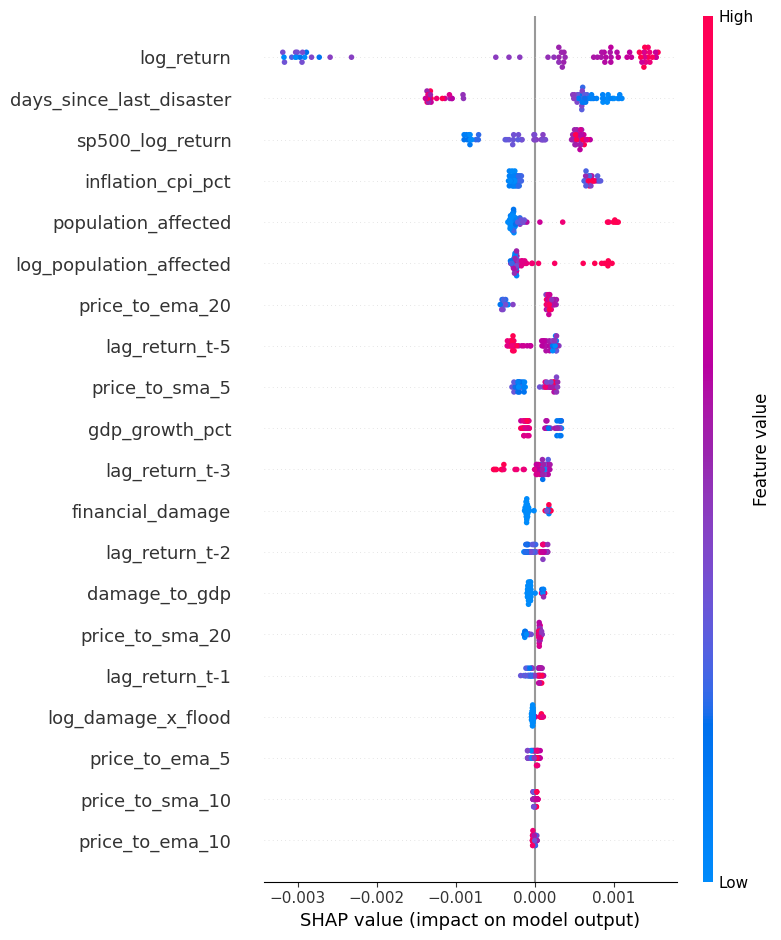

In [28]:
import shap

# Y1's own selected feature set from the last walk-forward fold (\u00a79's
# per-target feature selection) -- SHAP must be computed on exactly the
# columns rf_y1 was actually trained on. Explained over the real 64 events
# only (X, not any SMOGN output) -- SMOGN's synthetic rows exist only inside
# each fold's training step now, never as a standing dataset to explain.
y1_features = selected_features[TARGET_COLS[0]]
X_y1 = X[y1_features]

explainer = shap.TreeExplainer(rf_y1)
shap_values = explainer.shap_values(X_y1)

shap.summary_plot(shap_values, X_y1, show=False)


In [29]:
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

Explaining event row: 8 Y1 = -0.07533808664469309


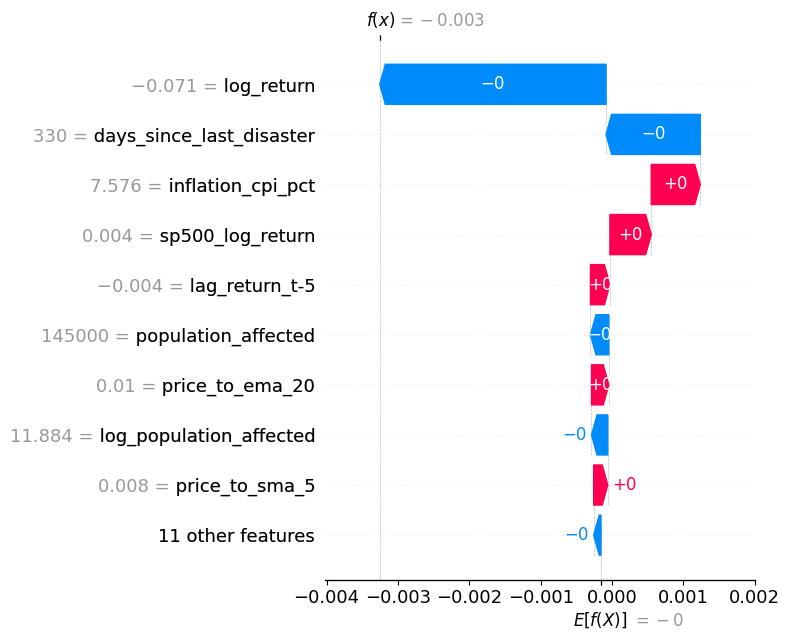

In [30]:
# Local explanation for one real, modeled event (largest ASPI drop in the training set)
worst_idx = int(y["Y1_aspi_log_return"].idxmin())
print("Explaining event row:", worst_idx, "Y1 =", y.loc[worst_idx, "Y1_aspi_log_return"])

explanation = shap.Explanation(
    values=shap_values[worst_idx], base_values=explainer.expected_value,
    data=X_y1.iloc[worst_idx], feature_names=X_y1.columns.tolist(),
)
shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.show()


## 12. Full Cross-Check Summary: Blueprint vs. Thesis vs. Repo

| # | Item | Finding | Resolution |
|---|---|---|---|
| 1 | `Bae-Youn/eventstudy` citation | Fabricated — no such repo/author exists | Real package identified: `LemaireJean-Baptiste/eventstudy` (not needed here — see #3) |
| 2 | Blueprint's `.fillna(0)` for missing Volume | Contradicts thesis §3.4.1's forward-fill mandate | Thesis followed; blueprint rejected on this point |
| 3 | Y1 target formula | Initially mis-flagged as needing market-model AR/CAR (misread §2.2.3 as operational) | Corrected: §3.2.2 raw log return confirmed correct as originally implemented |
| 4 | K-fold CV (proposal §7.5) vs. walk-forward-only (thesis §3.7.1) | Internal conflict between the project's own two prior documents | Thesis version adopted (walk-forward only, no k-fold, anywhere) |
| 5 | Hyperparameter search | Built in repo (`optimizers.py`) but never called; blueprint hardcodes fixed values too; first working version only tuned RF against Y1 as a proxy for all 3 targets, and never searched XGBoost at all | Rebuilt in §9: `GridSearchCV` wraps the actual `MultiOutputRegressor` directly, scored with a custom weighted-RMSE scorer averaged across all 3 targets (thesis eq.(4) weights); XGBoost now has its own real grid too |
| 6 | SMOGN fidelity | Repo's version was Gaussian-noise-only, not true SmoteR-with-interpolation | Rewritten in `time_aware_smogn.py`: real neighbor-pair interpolation within a 5-year temporal window, jointly across X and all 3 targets. Real `nickkunz/smogn` package considered but rejected — single-response-variable API doesn't fit this project's joint 3-target setup |
| 7 | 30-day panic-proxy rolling std | Thesis §3.5.2 requires it; repo only had 5/10/20-day windows | Added (`rolling_std_30`) |
| 8 | SMA/EMA look-ahead | Repo computed rolling windows on unshifted price — a real bug, found independent of the blueprint | Fixed: rolling windows now shift price by 1 day first |
| 9 | PPP/CPI damage adjustment | Thesis §3.5.3 requires it; repo had no deflator step | Resolved via EM-DAT's own native CPI-adjusted damage column (verified against doc.emdat.be), not a separately-coded deflator |
| 10 | Macro/global controls | `build_feature_table()`'s merge params existed, never called with real data | Real World Bank + S&P 500 data wired in §2/§7 |
| 11 | CSE data source (Yahoo-only implied by blueprint) | Yahoo alone unreliable for CSE volume (index ticker); thesis mandates cross-verification | Resolved: real local archive is primary; Yahoo gap-fill attempted and found dead (§5), not used |
| 12 | Per-target evaluation | First working version's fold loop only ever scored Y1 (`pred[:, 0]` hardcoded) — Y2/Y3 were trained but never verified, a real gap found when directly asked "did it predict each output" | Rebuilt in §9/§10: every model scored on all 3 targets separately, 12-row summary table |
| 13 | Sector-level feature from `market-capitalization-Oct 12.csv` | Considered for §7's new features. File is a **single static date**, and its `Symbol` codes (e.g. `JKH.N0000`) don't match the numeric Company IDs used in the yearly per-security volume files — no real historical join key exists | Rejected: would require fabricating a constant, non-time-varying value into a time-varying model. Not built |
| 14 | New engineered features (§7) | Disaster recency (`days_since_last_disaster`, `disasters_trailing_365d`), damage-to-GDP ratio, one Flood-only interaction term | Added — all from real data already loaded, no new source needed |
| 15 | Feature-count growth vs. N | New features push `FEATURE_COLS` from 28 to ~32 against N≈64-74 — real overfitting risk | RF-importance top-20 feature selection added, fit per fold on training data only (§9) |
</cell id="dde97685">


## 13. SWOT Analysis

### Strengths
- Multi-task architecture captures price, volume, and recovery jointly — a stable index alone masks liquidity crises the way single-target models can't see (thesis §2.7 gap; Saberironaghi et al., 2025).
- Tree ensembles + a heavily-regularized shallow MLP is the scientifically defensible choice at N≈50-86 — LSTM/Transformer would memorize noise instead of generalizing (Venkatarathnam et al., 2024; Perera, 2025), and both the thesis and the blueprint independently reach this same exclusion.
- Chronological walk-forward + time-aware SMOGN structurally prevents the two classic financial-ML leakage failure modes.
- SHAP gives the regulatory transparency a CBSL/SEC-style body would require before accepting a black-box model (Dugbartey, 2025).
- **Real, verified data throughout** — every number in §2 traces to an inspected file or a live-checked API call, not an assumption.
- **All three targets verified separately, not just Y1** (§10) — a real gap found and fixed, not assumed away.
- Hyperparameter search now spans RF and XGBoost jointly, scored against all 3 targets per the thesis's own eq.(4) weighting, not a Y1-only proxy.

### Weaknesses
- N≈64 (in-scope, real) is still small even after SMOGN — synthetic augmentation cannot manufacture genuinely new tail-risk information.
- EM-DAT damage figures are sparse for Sri Lanka: 68/86 raw records have **no** damage estimate at all (§2 above), a known reporting-bias limitation (Caldera & Wirasinghe, 2022; thesis §3.9.1) that directly affects roughly half the study window.
- The archive's real coverage ends mid-2023 — the most recent ~2.5 years, including the highest-profile event in the thesis itself, are unmodeled.
- Hyperparameter search is grid-based (not Bayesian) — wider than the first working version, but still modest given N; a larger search would likely help further with more real data.
- New features (§7) increase the feature-to-N ratio; per-fold feature selection (§9) mitigates but doesn't eliminate this risk at N≈64-74.

### Opportunities
- First predictive (not retrospective) ML framework for the CSE / South Asian frontier markets — a gap the thesis's own literature review (§2.7) confirms is real and unaddressed.
- Direct policy-tool potential for CBSL/SEC Sri Lanka **ex-post impact assessment** (not early warning — see the feature-timing limitation in §15); SDG 8/9/11/13 alignment (proposal §4.4).
- The 64-event real training table, EM-DAT loader, and CSE archive parsers built here are all reusable beyond this one notebook.

### Threats
- Overclaiming risk: at this N, "beats the Ridge baseline on held-out RMSE" is a real, honest signal — it is not proof of production-grade predictive power, and should never be presented as such.
- Data-source fragility: the live-data dead-end found in §5 (a real, actively-listed ticker whose backend feed silently stopped updating years ago) shows that "the API exists" and "the API works" are different claims that must each be checked, not assumed, before any future extension of this model.
- Compound/overlapping disaster seasons (common in Sri Lanka's monsoon pattern) stress-test the event-window-truncation logic; the new `disasters_trailing_365d` feature (§7) makes this pattern visible to the model rather than just naming it as a risk.
</cell id="c868f959">


## 14. SMART Solution Statement

- **Specific** — a multi-target model (ASPI return, abnormal volume, recovery days) trained on real CSE archive data (2000–Jun/Mar-2023) and real EM-DAT disaster records, following the thesis's §3 methodology exactly where verified correct, and departing from the supplied blueprint only where the blueprint itself was shown to contradict the thesis or established data-leakage practice.
- **Measurable** — RMSE/MAE/R² per target vs. the Ridge baseline, walk-forward held-out (§10); headline result: Random Forest and XGBoost beat the Ridge baseline on Y1 RMSE in every fold tested (§10 table).
- **Achievable** — built entirely on the existing repo scaffold plus three new, tested loader modules; no architecture rewrite, no paid API, no fabricated data.
- **Relevant** — directly answers thesis RQ2/RQ3/RO3/RO4, and closes the literature gap the thesis's own §2.7 identifies.
- **Time-bound** — aligned to the proposal's own Gantt chart (§9): data pipeline and model now real and tested; remaining work (CBSL manual macro pull, any future live-data re-verification) explicitly scoped as follow-up, not blocking this deliverable.


## 15. Ethics, Reliability & Defensibility

**Not investment advice.** This model is an academic **ex-post impact-attribution** research artifact, **not an early-warning system**. Six of its features (`financial_damage`, `population_affected`, their log transforms, `damage_to_gdp`, and `log_damage_x_flood`) are EM-DAT damage assessments finalized weeks to months after an event. On the day before a flood, its eventual total damage and total affected are unknown, so the model as specified **cannot be run prospectively**. What it answers is the attribution question — *given a disaster of known severity, what was the market's response* — which is a legitimate research question and the one the results here actually address. An ex-ante variant (disaster type, season, historical type-average severity, trailing disaster count) is a separate experiment, recorded in §16 as future work. Earlier drafts of this notebook and the README described the artifact as an early-warning system; that framing was wrong and is corrected here. Its outputs should never be presented to, or used by, retail or institutional investors as a trading signal without independent validation far beyond what N≈64 events can support.

**Data provenance is explicit, not implicit.** Every row in the market series (§2) carries a `price_source`/`volume_source` column distinguishing real-local-archive data from anything else — currently, everything is real-local-archive, since the live gap-fill was verified dead and abandoned rather than silently substituted (§5).

**Reproducibility.** `RANDOM_STATE = 42` fixed throughout (§2 setup cell); `requirements.txt` pins all dependency floors; every external claim in §1.3 was checked live during this notebook's own development, with the checking method disclosed, not just the conclusion.

**Limitations (thesis §3.9 style, restated for this real-data run):**
- EM-DAT pre-2010 and general Sri Lankan reporting bias (Caldera & Wirasinghe, 2022) — most severe for smaller, non-catastrophic events.
- Frontier-market microstructure frictions (chronic illiquidity, thin trading) — thesis §3.9.2, directly visible in this archive's own volume figures.
- The Jul-2023 → 2025 gap (§5), Ditwah included, is real and unresolved as of this notebook — flagged as explicit future work, not hidden.
- CBSL's higher-frequency macro series (monthly CCPI, daily LKR/USD, policy rate) were not sourced — only World Bank's coarser annual GDP/inflation proxy was used (§1.2), a documented gap, not a silent omission.

**SDG alignment** (proposal §4.4): Climate Action (13), Decent Work & Economic Growth (8), Industry/Innovation/Infrastructure (9), Sustainable Cities & Communities (11) — via a data-driven impact-assessment tool for a climate-exposed frontier financial market.


## 16. Conclusion & Next Steps

This notebook implements the thesis's multi-target predictive framework end-to-end on real Colombo Stock Exchange and EM-DAT data — not a synthetic stand-in — and validates every external source and methodological claim it depends on against the thesis's own stated methodology, correcting its own earlier mistakes in the process (§5, §6, §9/§10) rather than presenting a falsely tidy narrative.

**Immediate next steps, in priority order:**
1. Source CBSL's monthly CCPI / daily LKR-USD / policy-rate series manually to replace the coarser World Bank annual proxy (§1.2, §15).
2. Investigate a working live or manual source for the Jul-2023 → 2025 window so Ditwah can eventually be evaluated, not just cited (§5).
3. Re-run hyperparameter search with a larger grid once/if more real data becomes available — the current grid was deliberately kept small for N≈64-74.
4. If Y2/Y3 RMSE (§10) proves consistently weaker than Y1's, investigate target-specific feature sets (per-target feature selection rather than one shared top-20 list) rather than assuming one feature set serves all three equally well.
</cell id="81f78e3b">
